In [1]:
import numpy as np
import os as os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

%matplotlib inline

In [3]:
# ── CONFIG ──────────────────────────────────────────────────────────────────
CSV_PATH = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/r_scores_all_sequences_40_500ns.csv"
OUT_PATH = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/analysis_plots"

RESIDUES = [
    'R_58', 'R_59', 'R_62', 'R_83', 'R_87', 'R_88', 'R_89', 'R_92',
    'R_110', 'R_115', 'R_116', 'R_117', 'R_120', 'R_122',
    'R_159', 'R_160', 'R_163', 'R_164',
]

GROUP_ORDER = ['Binder', 'False Positive', 'Low Confidence', 'Fail Geometry']

# IBM colorblind-safe palette
GROUP_COLORS = {
    'Binder':         '#648FFF',   # blue
    'False Positive': '#DC267F',   # magenta
    'Low Confidence': '#FE6100',   # orange
    'Fail Geometry':  '#FFB000',   # gold
}

In [4]:
# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)

print(f"Loaded {len(df)} sequences")
print(df['seq_type'].value_counts().to_string())

missing = [c for c in RESIDUES if c not in df.columns]
if missing:
    raise ValueError(f"Columns missing from CSV: {missing}")

Loaded 192 sequences
seq_type
False Positive    120
Binder             53
Fail Geometry      10
Low Confidence      9


In [5]:
# ── 95% CONFIDENCE INTERVAL ──────────────────────────────────────────────────
def mean_ci95(arr):
    """
    Return (mean, ci_half_width) ignoring NaN.
    Uses t-distribution with n-1 degrees of freedom.
    CI half-width = t(0.975, n-1) * (std / sqrt(n))
    """
    a = arr.dropna()
    n = len(a)
    if n < 2:
        return a.mean(), np.nan
    m  = a.mean()
    se = a.std(ddof=1) / np.sqrt(n)
    t  = stats.t.ppf(0.975, df=n - 1)
    return m, t * se

# ── COMPUTE MEAN AND 95% CI PER GROUP PER RESIDUE ────────────────────────────
groups_present = [g for g in GROUP_ORDER if g in df['seq_type'].unique()]

stats_out = {}
for grp in groups_present:
    sub = df[df['seq_type'] == grp][RESIDUES]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in RESIDUES:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    stats_out[grp] = {'mean': means, 'ci': cis, 'n': n}

# Print summary table
header = f"{'Residue':<10}"
for grp in groups_present:
    header += f"  {grp+' (n='+str(stats_out[grp]['n'])+')':<28}"
print(header)
print('-' * len(header))
for j, res in enumerate(RESIDUES):
    row = f"{res:<10}"
    for grp in groups_present:
        m  = stats_out[grp]['mean'][j]
        ci = stats_out[grp]['ci'][j]
        row += f"  {m:>6.3f} +/- {ci:>5.3f}           "
    print(row)

Residue     Binder (n=53)                 False Positive (n=120)        Low Confidence (n=9)          Fail Geometry (n=10)        
----------------------------------------------------------------------------------------------------------------------------------
R_58        -0.164 +/- 0.055             -0.051 +/- 0.047             -0.084 +/- 0.257              0.075 +/- 0.261           
R_59         0.052 +/- 0.051              0.159 +/- 0.036              0.268 +/- 0.244              0.119 +/- 0.269           
R_62        -0.008 +/- 0.031              0.123 +/- 0.028              0.099 +/- 0.093              0.277 +/- 0.112           
R_83         0.264 +/- 0.046              0.209 +/- 0.039              0.066 +/- 0.059              0.210 +/- 0.191           
R_87         0.056 +/- 0.015              0.072 +/- 0.025              0.047 +/- 0.025              0.025 +/- 0.062           
R_88         0.015 +/- 0.044              0.002 +/- 0.024              0.030 +/- 0.054             -0.1

In [6]:
# ── GROUPED NONBINDER STATS ──────────────────────────────────────────────────
# Add a combined 'Nonbinder' group pooling FP, Low Confidence, Fail Geometry
NONBINDER_TYPES = ['False Positive', 'Low Confidence', 'Fail Geometry']
GROUPED_ORDER   = ['Binder', 'Nonbinder']
GROUPED_COLORS  = {
    'Binder':    '#648FFF',   # blue  — same as before
    'Nonbinder': '#DC267F',   # magenta
}

# Create a copy of df with nonbinder subtypes relabelled
df_grouped = df.copy()
df_grouped.loc[df_grouped['seq_type'].isin(NONBINDER_TYPES), 'seq_type'] = 'Nonbinder'

# Compute stats for grouped version
stats_grouped = {}
for grp in GROUPED_ORDER:
    sub = df_grouped[df_grouped['seq_type'] == grp][RESIDUES]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in RESIDUES:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    stats_grouped[grp] = {'mean': means, 'ci': cis, 'n': n}

n_nb = stats_grouped['Nonbinder']['n']
print(f"Nonbinder group: n={n_nb} "
      f"(FP={len(df[df['seq_type']=='False Positive'])} + "
      f"LC={len(df[df['seq_type']=='Low Confidence'])} + "
      f"FG={len(df[df['seq_type']=='Fail Geometry'])})"
)


# ── REUSABLE PLOT HELPER ─────────────────────────────────────────────────────
def bar_plot(ax, residues, groups, stats_data, colors, title,
             ylim=(-1, 1), spacing=2):
    """
    Draw a grouped bar chart on ax.
    spacing: multiplier on residue cluster spacing (use 2 for wider gaps).
    """
    n_grp = len(groups)
    n_res = len(residues)
    bw    = 0.8 / n_grp
    x     = np.arange(n_res) * spacing

    for i, grp in enumerate(groups):
        offsets = x - 0.4 + bw * (i + 0.5)
        means   = stats_data[grp]['mean']
        cis     = stats_data[grp]['ci']
        n       = stats_data[grp]['n']
        ax.bar(offsets, means, width=bw,
               color=colors.get(grp, '#888888'),
               label=f"{grp} (n={n})",
               alpha=0.85, edgecolor='k', linewidth=0.3)
        ax.errorbar(offsets, means, yerr=cis,
                    fmt='none', color='k', linewidth=0.9,
                    capsize=2.5, capthick=0.9)

    ax.axhline(0, color='grey', linewidth=0.6, alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([r.replace('R_', '') for r in residues], fontsize=9)
    ax.set_xlabel('Residue position', fontsize=10)
    ax.set_ylabel('R-score', fontsize=10)
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    handles = [mpatches.Patch(color=colors.get(g, '#888888'),
                               label=f"{g} (n={stats_data[g]['n']})")
               for g in groups]
    ax.legend(handles=handles, fontsize=8, loc='lower right')

def get_stats(residues, groups=None):
    """
    Compute mean and 95% CI per group per residue.
    Defaults to groups_present if groups not specified.
    """
    if groups is None:
        groups = groups_present
    out = {}
    for grp in groups:
        sub = df[df['seq_type'] == grp][residues]
        n   = int(sub.notna().sum().iloc[0])
        out[grp] = {}
        for res in residues:
            m, ci = mean_ci95(sub[res])
            out[grp][res] = {'mean': m, 'ci': ci, 'n': n}
    return out


# Key residues for strip plots (Figure 8)
STRIP_RES = ['R_88', 'R_58', 'R_122', 'R_160', 'R_83', 'R_163']

Nonbinder group: n=139 (FP=120 + LC=9 + FG=10)


## Figure 1 - overview

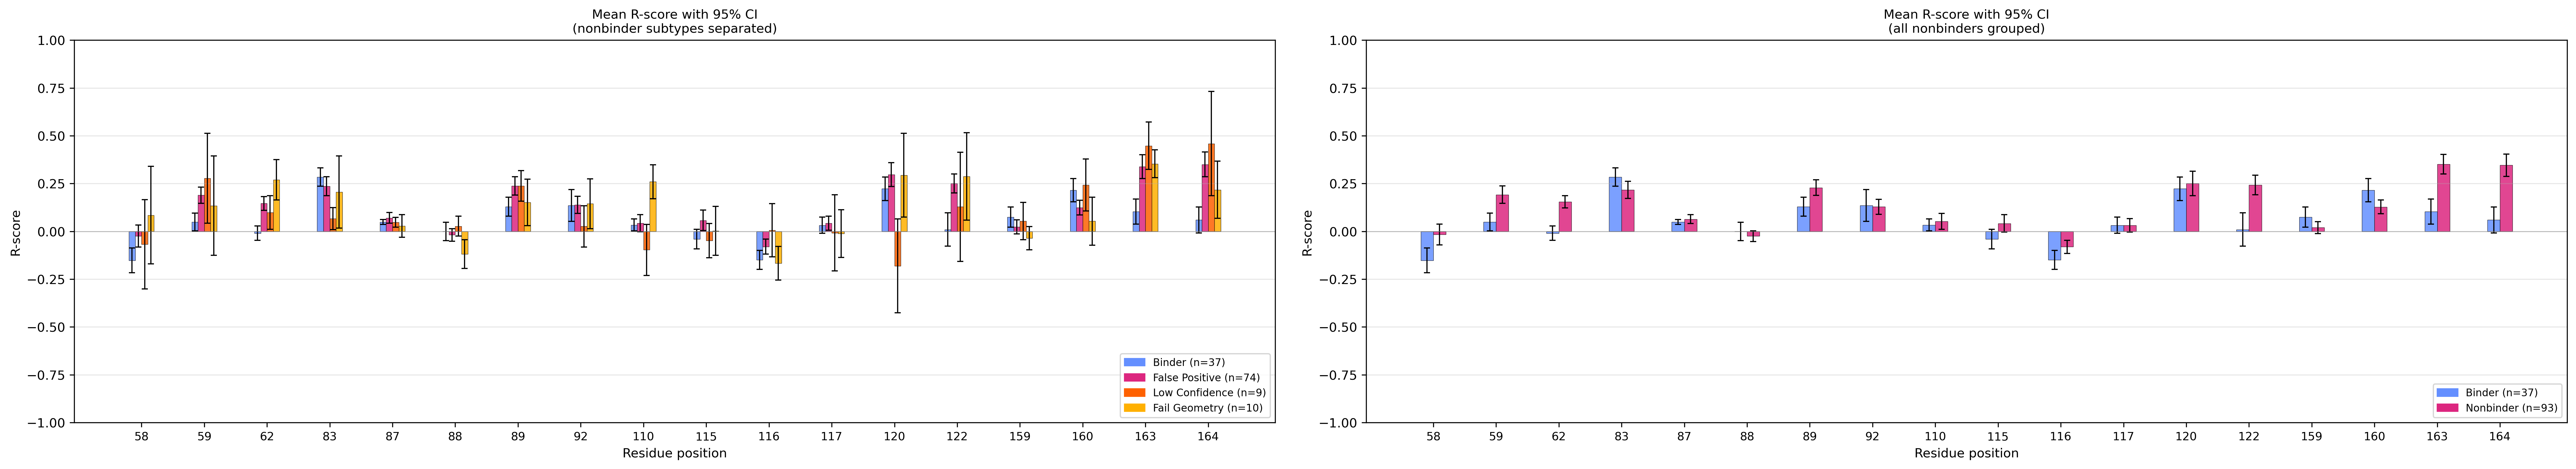

In [7]:
# ── FIGURE 1: overview — separated subtypes (left) and grouped (right) ───────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(28, 5),
                                constrained_layout=True, dpi=300)

bar_plot(ax1, RESIDUES, groups_present, stats_out, GROUP_COLORS,
         'Mean R-score with 95% CI\n(nonbinder subtypes separated)',
         spacing=2)

bar_plot(ax2, RESIDUES, GROUPED_ORDER, stats_grouped, GROUPED_COLORS,
         'Mean R-score with 95% CI\n(all nonbinders grouped)',
         spacing=2)

plt.show()
fig.savefig(os.path.join(OUT_PATH,    'avg_Rscore_seq_type.png'), dpi=300, bbox_inches='tight')

## Figure 2 — Gate region (P88, H115)

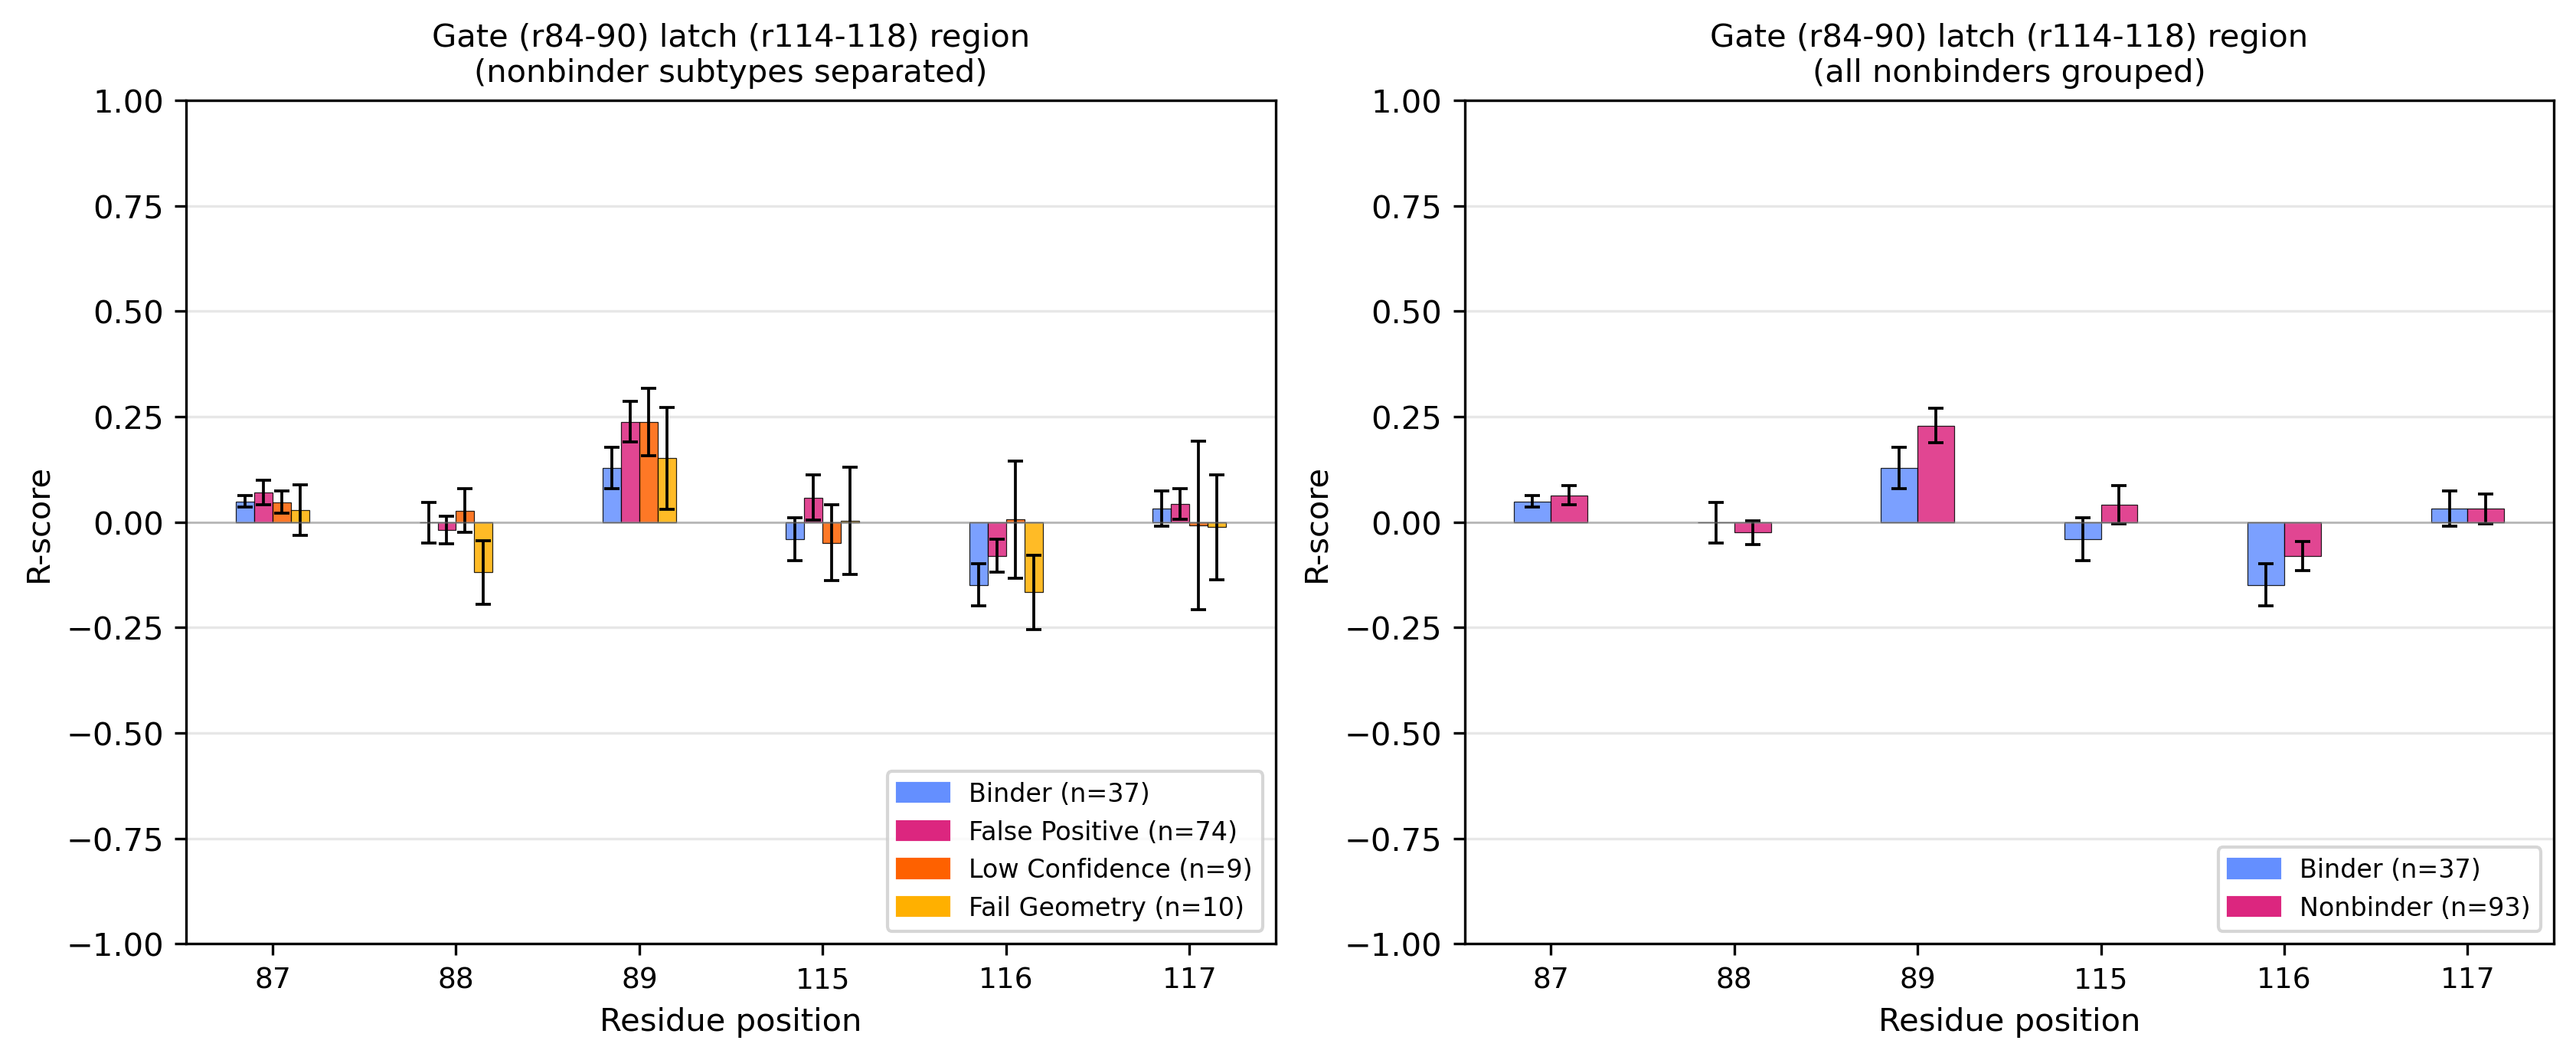

In [8]:
# ── FIGURE 2: Gate region (P88, H115) ─────────────────────────────────────────────
residues = ['R_87', 'R_88', 'R_89', 'R_115', 'R_116', 'R_117']
title    = 'Gate (r84-90) latch (r114-118) region'

# Recompute stats restricted to this residue subset
s_sub = {}
for grp in groups_present:
    sub = df[df['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_sub[grp] = {'mean': means, 'ci': cis, 'n': n}

s_grp = {}
for grp in GROUPED_ORDER:
    sub = df_grouped[df_grouped['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_grp[grp] = {'mean': means, 'ci': cis, 'n': n}

ylim = (-1, 1)
w1, w2 = 6.6000000000000005, 4.5

fig, (ax1, ax2) = plt.subplots(1, 2,
                                figsize=(w1 + w2, 4.5),
                                constrained_layout=True, dpi=300)

bar_plot(ax1, residues, groups_present, s_sub, GROUP_COLORS,
         title + '\n(nonbinder subtypes separated)', ylim=ylim)
bar_plot(ax2, residues, GROUPED_ORDER,  s_grp, GROUPED_COLORS,
         title + '\n(all nonbinders grouped)',      ylim=ylim)

plt.show()
fig.savefig(os.path.join(OUT_PATH,    'Rscore_gate.png'), dpi=300, bbox_inches='tight')


## Figure 3 — Hydrophobic packing (83, 159, 160)

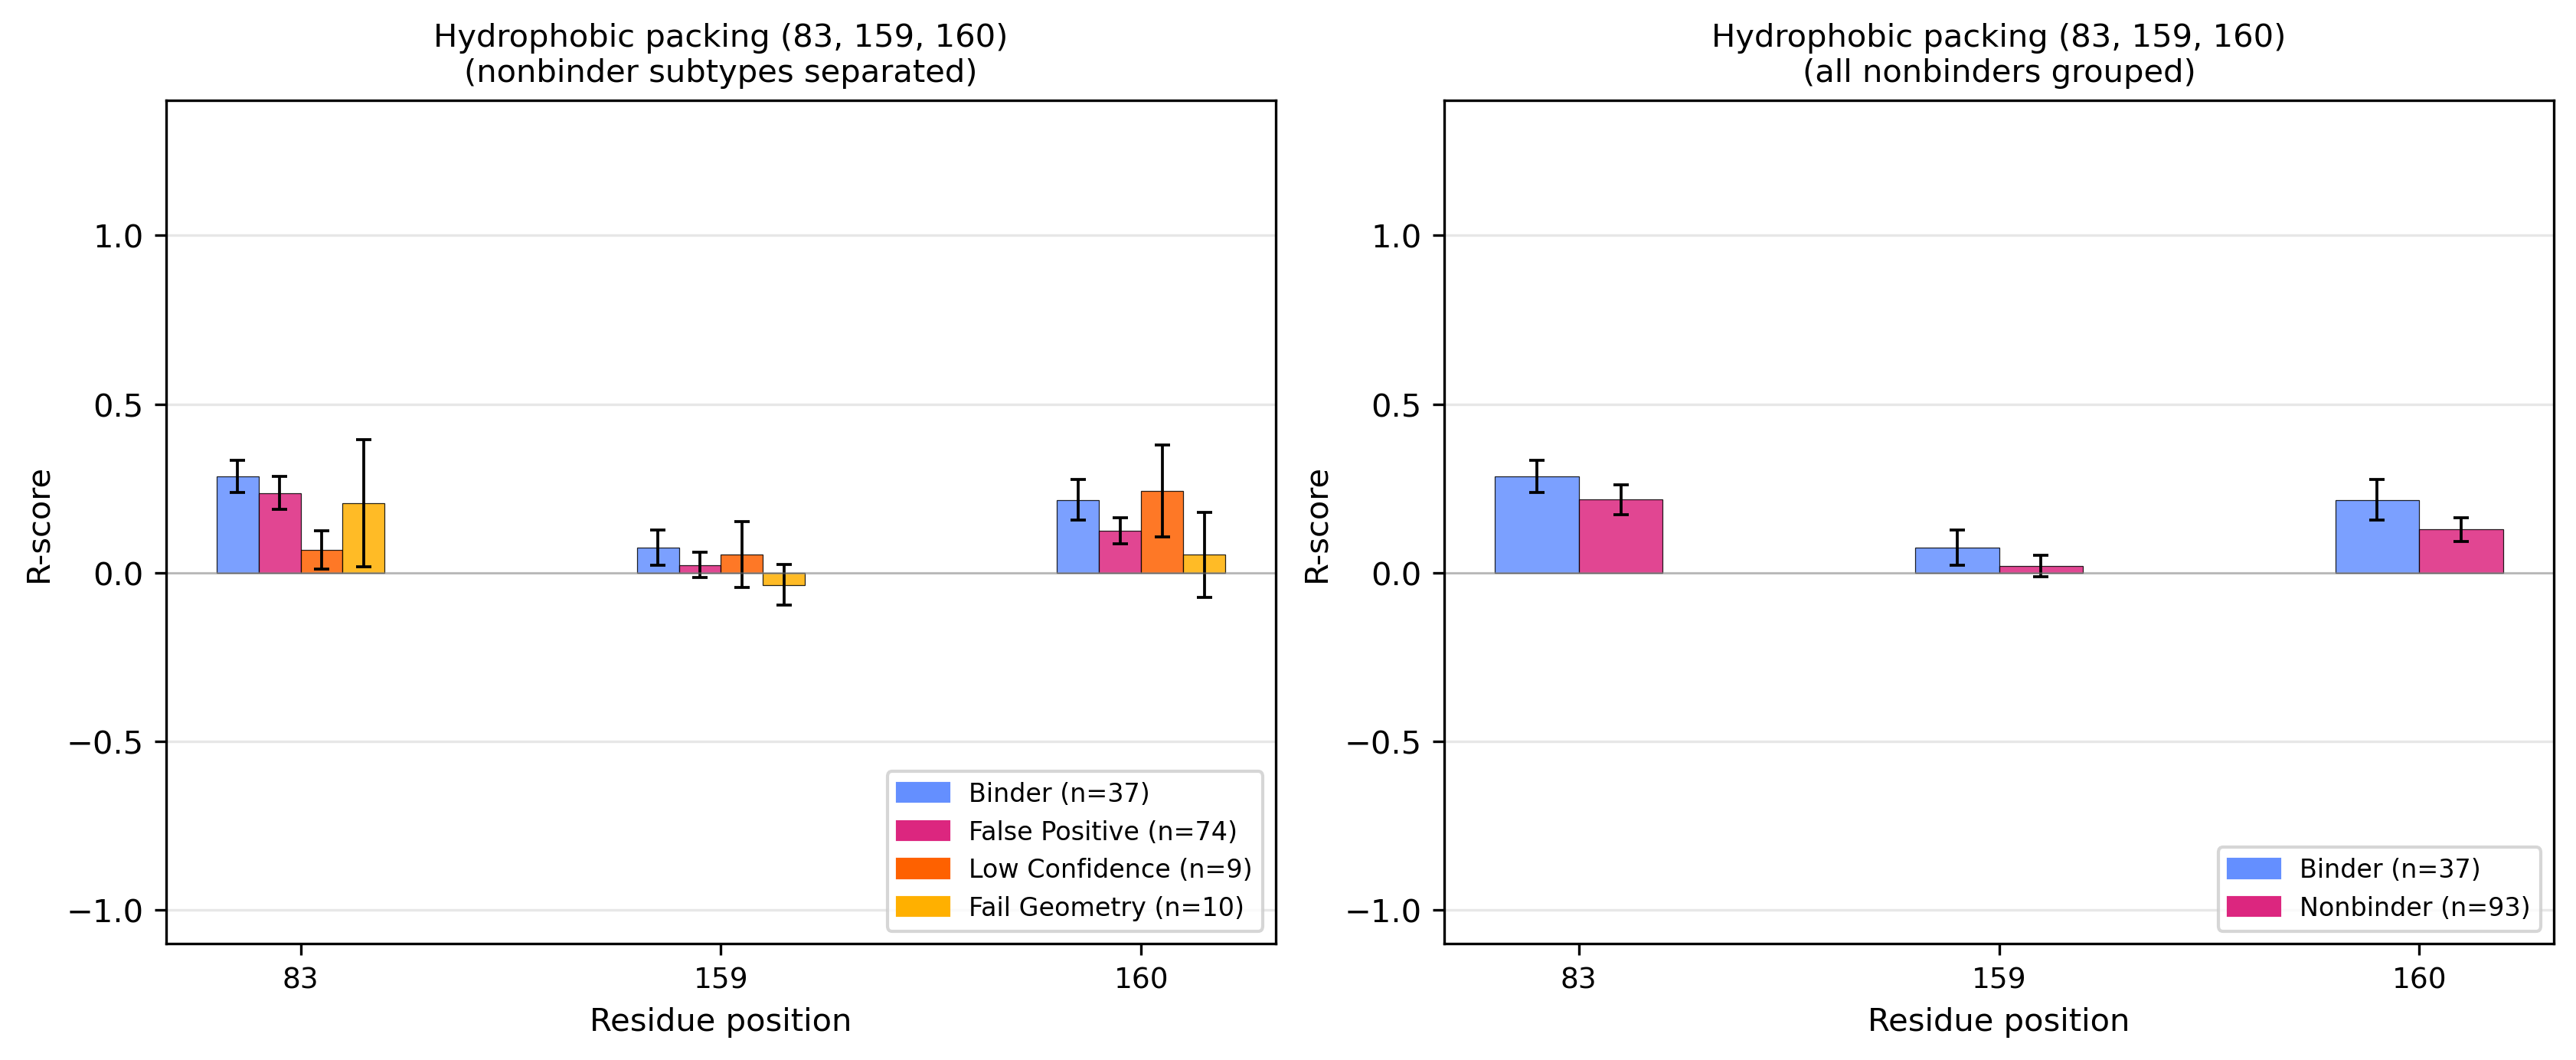

In [9]:
# ── FIGURE 3: Hydrophobic packing (83, 159, 160) ─────────────────────────────────────────────
residues = ['R_83', 'R_159', 'R_160']
title    = 'Hydrophobic packing (83, 159, 160)'

# Recompute stats restricted to this residue subset
s_sub = {}
for grp in groups_present:
    sub = df[df['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_sub[grp] = {'mean': means, 'ci': cis, 'n': n}

s_grp = {}
for grp in GROUPED_ORDER:
    sub = df_grouped[df_grouped['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_grp[grp] = {'mean': means, 'ci': cis, 'n': n}

ylim = (-1.1, 1.4)
w1, w2 = 6.6000000000000005, 4.5

fig, (ax1, ax2) = plt.subplots(1, 2,
                                figsize=(w1 + w2, 4.5),
                                constrained_layout=True, dpi=300)

bar_plot(ax1, residues, groups_present, s_sub, GROUP_COLORS,
         title + '\n(nonbinder subtypes separated)', ylim=ylim)
bar_plot(ax2, residues, GROUPED_ORDER,  s_grp, GROUPED_COLORS,
         title + '\n(all nonbinders grouped)',      ylim=ylim)

plt.show()
fig.savefig(os.path.join(OUT_PATH,    'Rscore_hydrophobic_83_159_160.png'), dpi=300, bbox_inches='tight')


## Figure 4 — Position 58

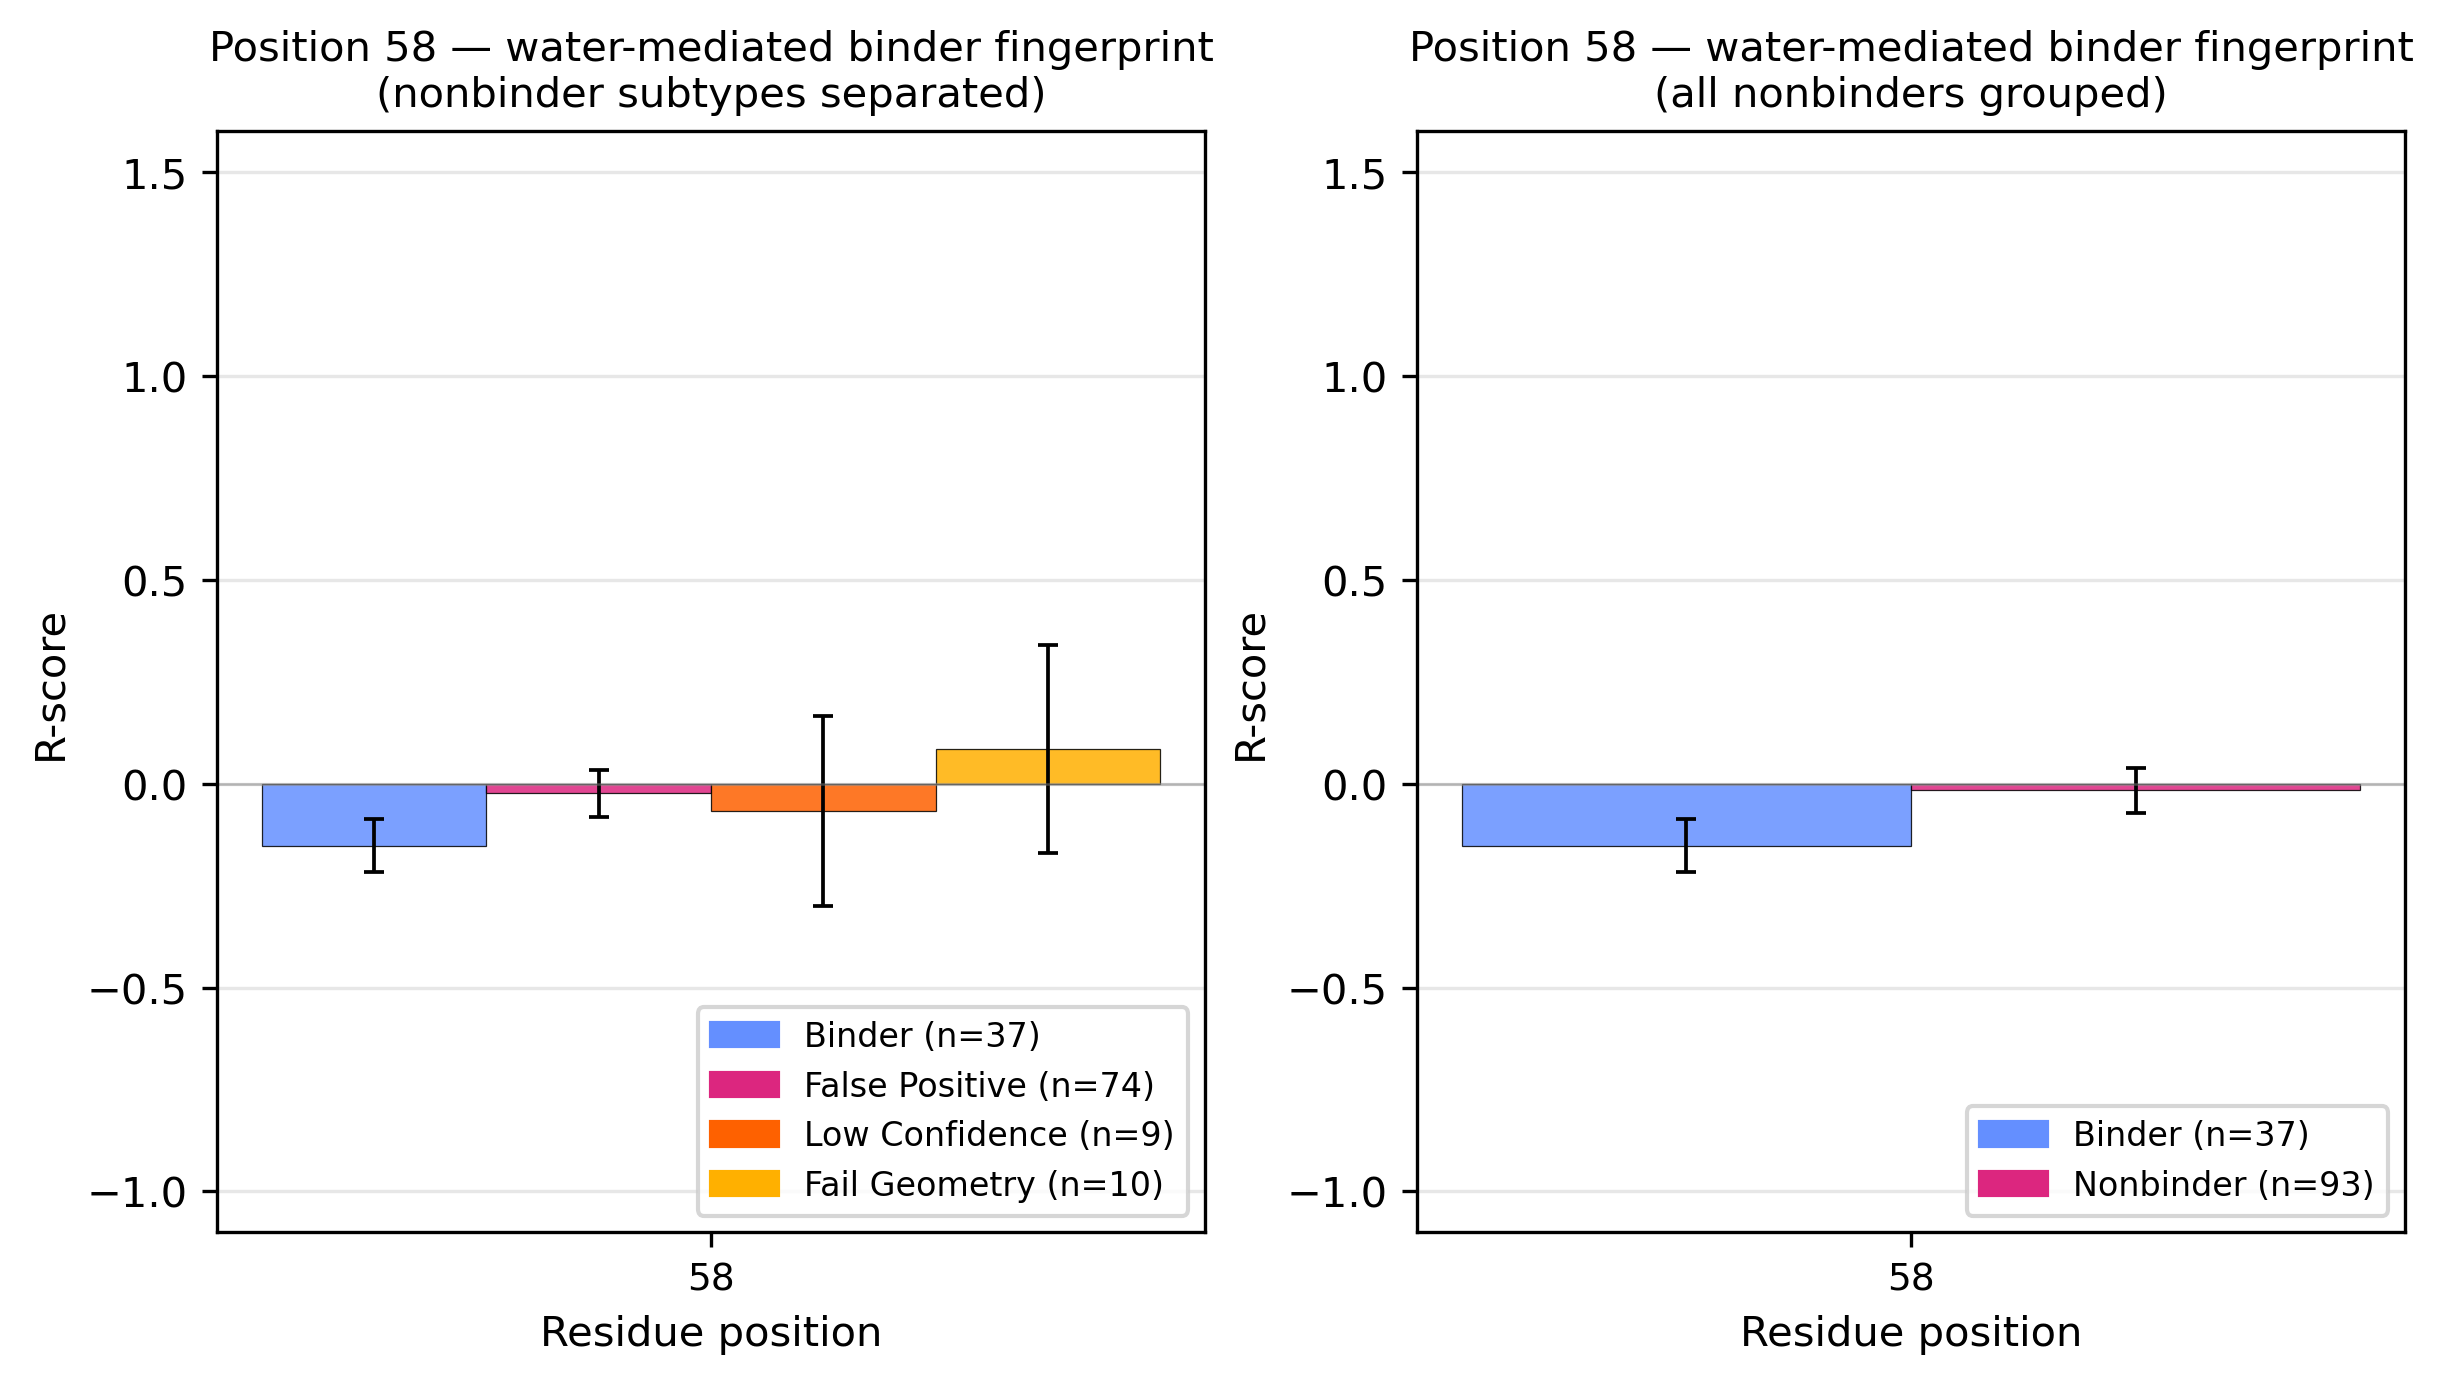

In [10]:
# ── FIGURE 4: Position 58 — water-mediated binder fingerprint ─────────────────────────────────────────────
residues = ['R_58']
title    = 'Position 58 — water-mediated binder fingerprint'

# Recompute stats restricted to this residue subset
s_sub = {}
for grp in groups_present:
    sub = df[df['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_sub[grp] = {'mean': means, 'ci': cis, 'n': n}

s_grp = {}
for grp in GROUPED_ORDER:
    sub = df_grouped[df_grouped['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_grp[grp] = {'mean': means, 'ci': cis, 'n': n}

ylim = (-1.1, 1.6)
w1, w2 = 5, 3

fig, (ax1, ax2) = plt.subplots(1, 2,
                                figsize=(w1 + w2, 4.5),
                                constrained_layout=True, dpi=300)

bar_plot(ax1, residues, groups_present, s_sub, GROUP_COLORS,
         title + '\n(nonbinder subtypes separated)', ylim=ylim)
bar_plot(ax2, residues, GROUPED_ORDER,  s_grp, GROUPED_COLORS,
         title + '\n(all nonbinders grouped)',      ylim=ylim)

plt.show()
fig.savefig(os.path.join(OUT_PATH,    'Rscore_58.png'), dpi=300, bbox_inches='tight')


## Figure 5 — Bottom of pocket (122, 163, 164)

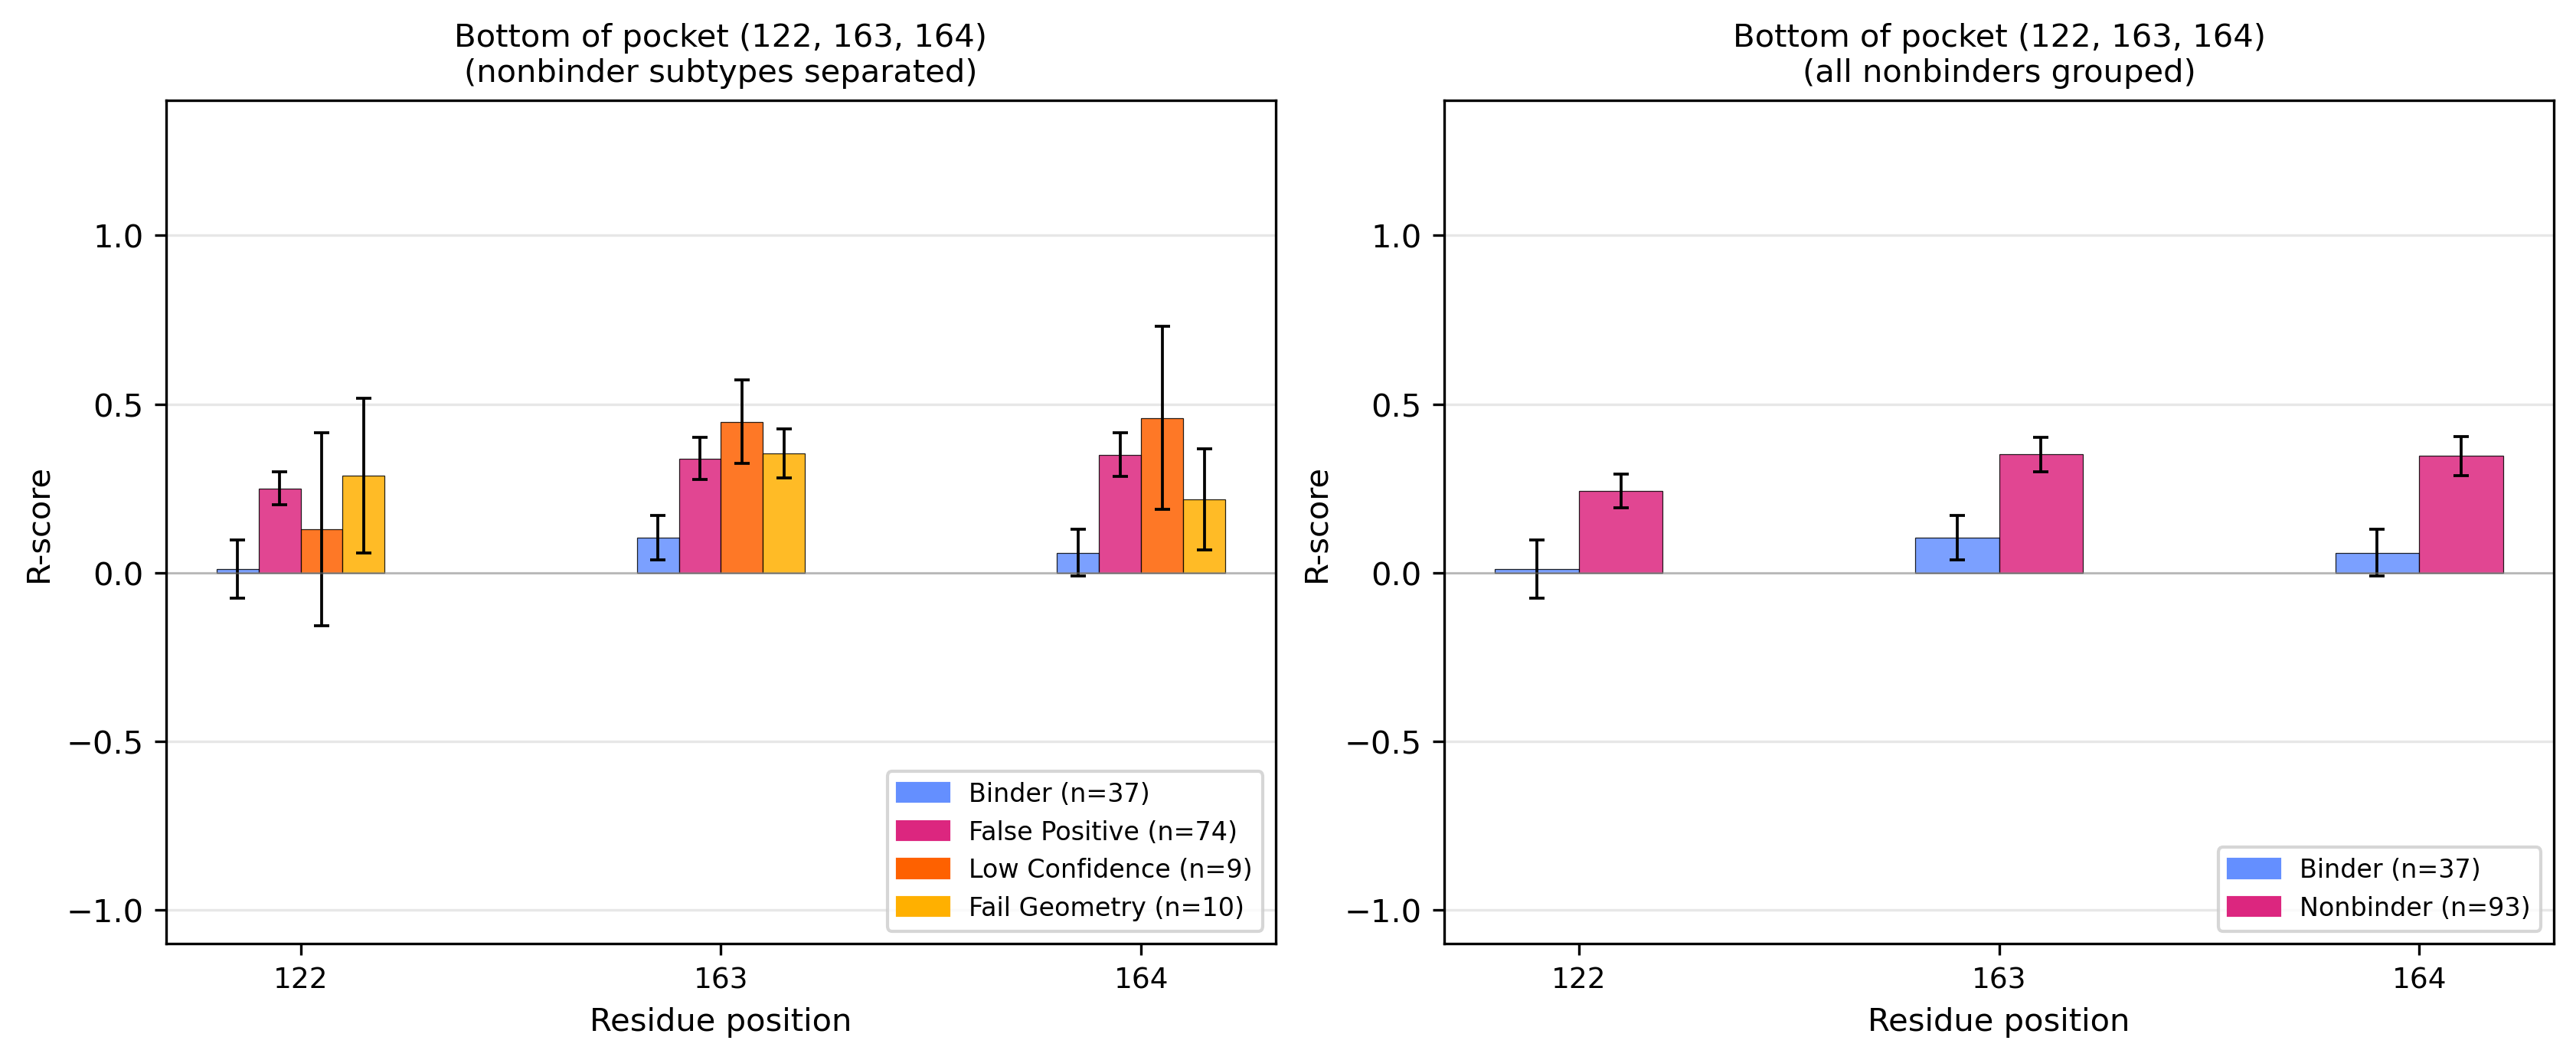

In [11]:
# ── FIGURE 5: Bottom of pocket (122, 163, 164) ─────────────────────────────────────────────
residues = ['R_122', 'R_163', 'R_164']
title    = 'Bottom of pocket (122, 163, 164)'

# Recompute stats restricted to this residue subset
s_sub = {}
for grp in groups_present:
    sub = df[df['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_sub[grp] = {'mean': means, 'ci': cis, 'n': n}

s_grp = {}
for grp in GROUPED_ORDER:
    sub = df_grouped[df_grouped['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_grp[grp] = {'mean': means, 'ci': cis, 'n': n}

ylim = (-1.1, 1.4)
w1, w2 = 6.6000000000000005, 4.5

fig, (ax1, ax2) = plt.subplots(1, 2,
                                figsize=(w1 + w2, 4.5),
                                constrained_layout=True, dpi=300)

bar_plot(ax1, residues, groups_present, s_sub, GROUP_COLORS,
         title + '\n(nonbinder subtypes separated)', ylim=ylim)
bar_plot(ax2, residues, GROUPED_ORDER,  s_grp, GROUPED_COLORS,
         title + '\n(all nonbinders grouped)',      ylim=ylim)

plt.show()
fig.savefig(os.path.join(OUT_PATH,    'Rscores_bottom_res_122_163_164.png'), dpi=300, bbox_inches='tight')


## Figure 6 — Additional discriminating positions (59, 62, 110)

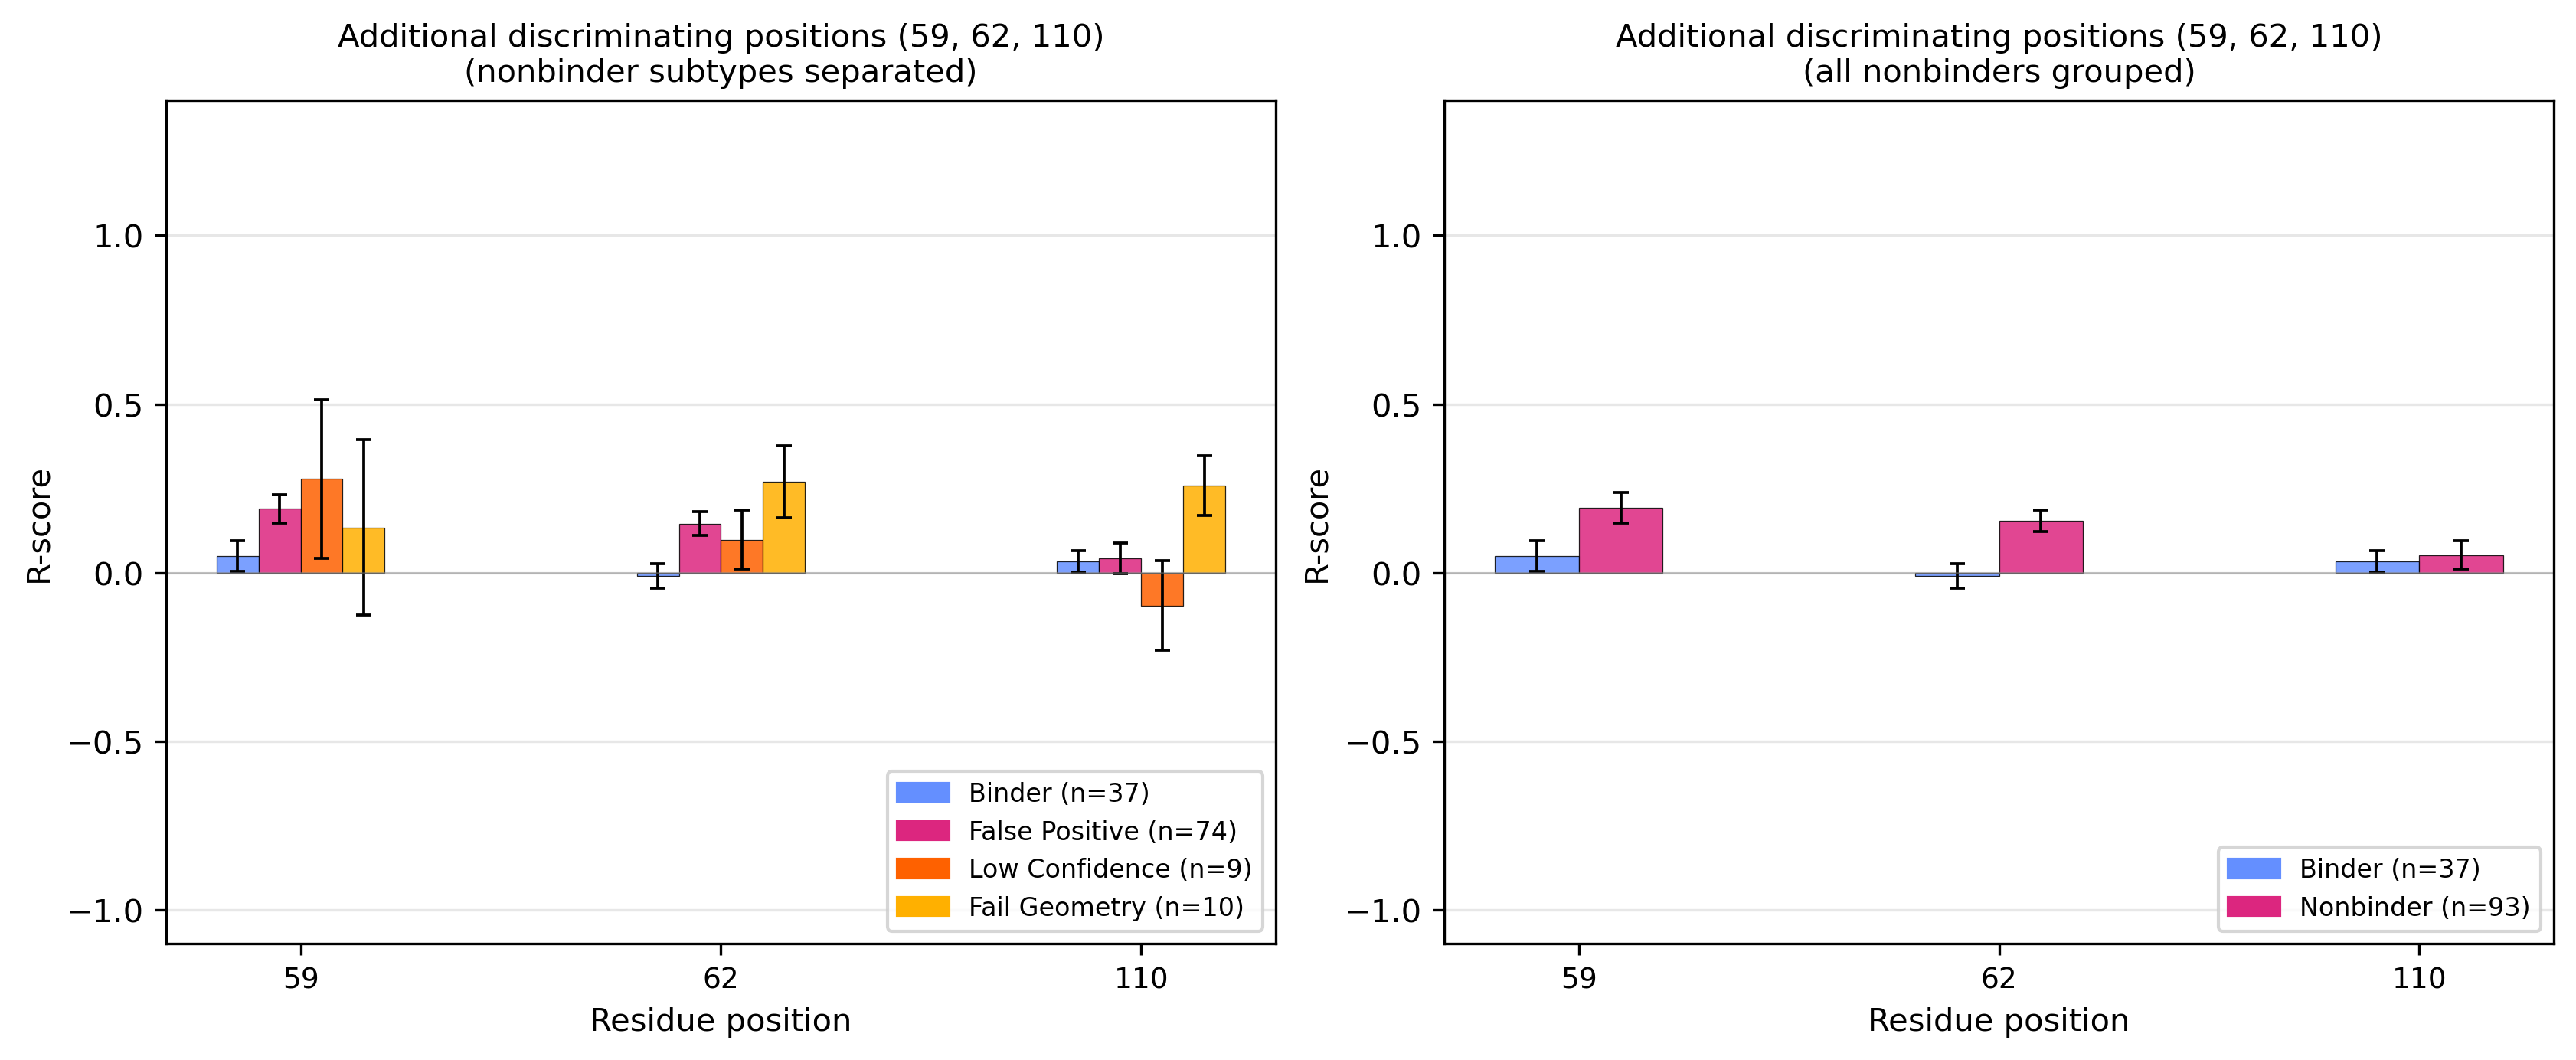

In [12]:
# ── FIGURE 6: Additional discriminating positions (59, 62, 110) ─────────────────────────────────────────────
residues = ['R_59', 'R_62', 'R_110']
title    = 'Additional discriminating positions (59, 62, 110)'

# Recompute stats restricted to this residue subset
s_sub = {}
for grp in groups_present:
    sub = df[df['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_sub[grp] = {'mean': means, 'ci': cis, 'n': n}

s_grp = {}
for grp in GROUPED_ORDER:
    sub = df_grouped[df_grouped['seq_type'] == grp][residues]
    n   = int(sub.notna().sum().iloc[0])
    means, cis = [], []
    for res in residues:
        m, ci = mean_ci95(sub[res])
        means.append(m)
        cis.append(ci)
    s_grp[grp] = {'mean': means, 'ci': cis, 'n': n}

ylim = (-1.1, 1.4)
w1, w2 = 6.6000000000000005, 4.5

fig, (ax1, ax2) = plt.subplots(1, 2,
                                figsize=(w1 + w2, 4.5),
                                constrained_layout=True, dpi=300)

bar_plot(ax1, residues, groups_present, s_sub, GROUP_COLORS,
         title + '\n(nonbinder subtypes separated)', ylim=ylim)
bar_plot(ax2, residues, GROUPED_ORDER,  s_grp, GROUPED_COLORS,
         title + '\n(all nonbinders grouped)',      ylim=ylim)

plt.show()
fig.savefig(os.path.join(OUT_PATH, 'Rscores_59_62_110.png'), dpi=300, bbox_inches='tight')


## Figure 7 — Heatmap: mean R-score across all residues

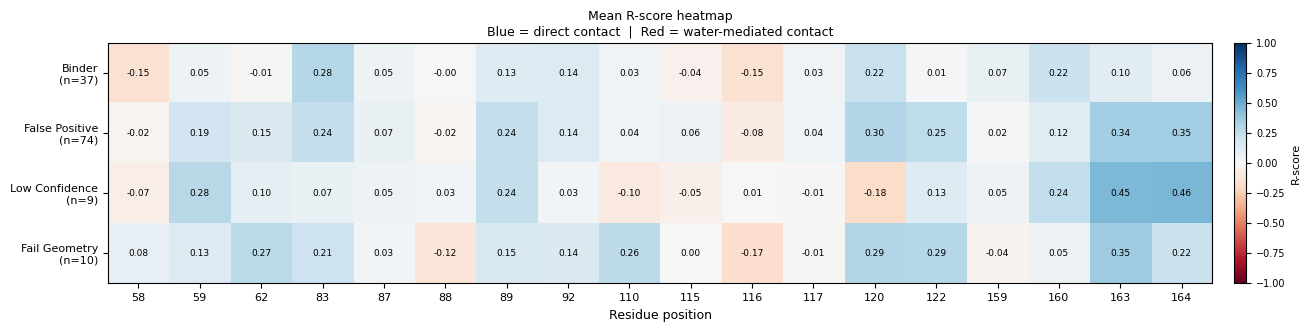

In [13]:
# ── HEATMAP ──────────────────────────────────────────────────────────────────
s_all  = get_stats(RESIDUES)
matrix = np.array([[s_all[grp][res]['mean'] for res in RESIDUES]
                    for grp in groups_present])

fig, ax = plt.subplots(figsize=(13, 3.2), constrained_layout=True)
norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
im   = ax.imshow(matrix, aspect='auto', cmap='RdBu', norm=norm)

for i, grp in enumerate(groups_present):
    for j, res in enumerate(RESIDUES):
        m = s_all[grp][res]['mean']
        ax.text(j, i, f"{m:.2f}", ha='center', va='center',
                fontsize=6.5,
                color='white' if abs(m) > 0.5 else 'black')

ax.set_xticks(range(len(RESIDUES)))
ax.set_xticklabels([r.replace('R_','') for r in RESIDUES], fontsize=8)
ax.set_yticks(range(len(groups_present)))
ax.set_yticklabels(
    [f"{g}\n(n={s_all[g][RESIDUES[0]]['n']})" for g in groups_present],
    fontsize=8)
ax.set_xlabel('Residue position', fontsize=9)
ax.set_title(
    'Mean R-score heatmap\nBlue = direct contact  |  Red = water-mediated contact',
    fontsize=9)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('R-score', fontsize=8)
cbar.ax.tick_params(labelsize=7)
plt.show()

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig.savefig(os.path.join(OUT_PATH, f"avg_Rscore_heatmap.png"), dpi=300, bbox_inches="tight")

## Figure 8 — Strip plots: individual sequences for key residues

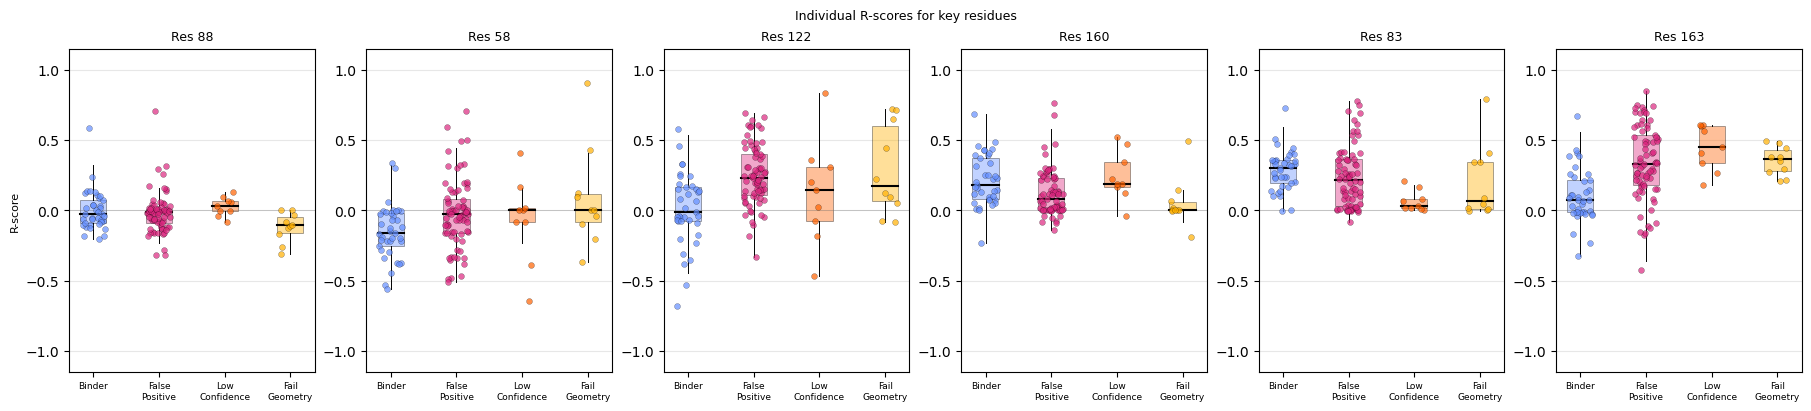

In [14]:
# ── STRIP PLOTS ──────────────────────────────────────────────────────────────
rng  = np.random.default_rng(42)
fig, axes = plt.subplots(1, len(STRIP_RES), figsize=(3.0 * len(STRIP_RES), 4.0), constrained_layout=True)

for ax, res in zip(axes, STRIP_RES):
    for i, grp in enumerate(groups_present):
        vals   = df[df['seq_type'] == grp][res].dropna().values
        jitter = rng.uniform(-0.18, 0.18, size=len(vals))

        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr = q3 - q1
        lo  = max(vals.min(), q1 - 1.5 * iqr)
        hi  = min(vals.max(), q3 + 1.5 * iqr)

        ax.plot([i-0.2, i+0.2], [med, med],
                color='k', linewidth=1.5, zorder=4)
        rect = plt.Rectangle((i-0.2, q1), 0.4, iqr,
                               facecolor=GROUP_COLORS[grp],
                               edgecolor='k', linewidth=0.6,
                               alpha=0.4, zorder=2)
        ax.add_patch(rect)
        ax.plot([i, i], [lo, q1], color='k', linewidth=0.7, zorder=3)
        ax.plot([i, i], [q3, hi], color='k', linewidth=0.7, zorder=3)
        ax.scatter(i + jitter, vals,
                   color=GROUP_COLORS[grp], s=18, alpha=0.7,
                   edgecolors='k', linewidths=0.2, zorder=5)

    ax.axhline(0,    color='grey', linewidth=0.5, alpha=0.5)
    #ax.axhline(-0.7, color='k',    linewidth=0.7, linestyle='--', alpha=0.6)
    ax.set_xticks(range(len(groups_present)))
    ax.set_xticklabels([g.replace(' ', '\n') for g in groups_present], fontsize=6.5)
    ax.set_title(res.replace('R_', 'Res '), fontsize=9)
    ax.set_ylabel('R-score' if ax is axes[0] else '', fontsize=8)
    ax.set_ylim(-1.15, 1.15)
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Individual R-scores for key residues', fontsize=9)
plt.show()

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig.savefig(os.path.join(OUT_PATH, f"boxplot_Rscores.png"),   dpi=300, bbox_inches="tight")

## D and W contact occupancy analysis

In [7]:
# ── LOAD D/W SCORES ──────────────────────────────────────────────────────────
DW_PATH = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/dw_scores_all_sequences_40_500ns.csv"

df_dw = pd.read_csv(DW_PATH)

# Extract D and W column names for the key pocket residues
D_COLS = [f'D_{r}' for r in [int(x.replace('R_','')) for x in RESIDUES]]
W_COLS = [f'W_{r}' for r in [int(x.replace('R_','')) for x in RESIDUES]]

# Verify all expected columns exist
missing_d = [c for c in D_COLS if c not in df_dw.columns]
missing_w = [c for c in W_COLS if c not in df_dw.columns]
if missing_d or missing_w:
    raise ValueError(f'Missing columns — D: {missing_d}  W: {missing_w}')

print(f'Loaded {len(df_dw)} sequences, {len(D_COLS)} D columns, {len(W_COLS)} W columns')
print(df_dw['seq_type'].value_counts().to_string())

Loaded 192 sequences, 18 D columns, 18 W columns
seq_type
False Positive    120
Binder             53
Fail Geometry      10
Low Confidence      9


In [8]:
# ── AVERAGE D AND W PER GROUP PER RESIDUE ────────────────────────────────────
# Reuse mean_ci95 from cell 4 — D and W occupancies are continuous [0,1]
# so the same t-distribution CI applies.

res_labels = [r.replace('R_', '') for r in RESIDUES]

dw_stats = {}   # {group: {'D': {resSeq: {'mean','ci','n'}}, 'W': {...}}}

for grp in groups_present:
    sub    = df_dw[df_dw['seq_type'] == grp]
    d_res  = {}
    w_res  = {}
    for d_col, w_col, res in zip(D_COLS, W_COLS, res_labels):
        m_d, ci_d = mean_ci95(sub[d_col])
        m_w, ci_w = mean_ci95(sub[w_col])
        d_res[res] = {'mean': m_d, 'ci': ci_d, 'n': sub[d_col].notna().sum()}
        w_res[res] = {'mean': m_w, 'ci': ci_w, 'n': sub[w_col].notna().sum()}
    dw_stats[grp] = {'D': d_res, 'W': w_res}

# Print summary table
print(f'\n{"Residue":<8}', end='')
for grp in groups_present:
    n = dw_stats[grp]['D'][res_labels[0]]['n']
    print(f'  {grp[:12]+" (n="+str(n)+")":<24}', end='')
print()
print(f'{"":8}', end='')
for grp in groups_present:
    print(f'  {"D mean":>10}  {"W mean":>10}  ', end='')
print()
print('-' * (8 + 26 * len(groups_present)))
for res in res_labels:
    print(f'{res:<8}', end='')
    for grp in groups_present:
        m_d = dw_stats[grp]['D'][res]['mean']
        m_w = dw_stats[grp]['W'][res]['mean']
        print(f'  {m_d:>10.4f}  {m_w:>10.4f}  ', end='')
    print()

# ── SAVE PER-SEQUENCE D AND W FOR ALL RESIDUES → ML FEATURE CSV ─────────────
# Saves D and W for all 181 residues (not just the 18 key pocket residues),
# with columns interleaved as D_1, W_1, D_2, W_2, ... D_181, W_181.
# D and W are zero-filled (not NaN) since zero occupancy is a real measurement.

all_d_cols = [c for c in df_dw.columns if c.startswith('D_')]
all_w_cols = [c for c in df_dw.columns if c.startswith('W_')]

# Interleave D and W columns: D_1, W_1, D_2, W_2, ...
interleaved = ['seq_id', 'seq_type']
for d_col, w_col in zip(all_d_cols, all_w_cols):
    interleaved.append(d_col)
    interleaved.append(w_col)

df_ml = df_dw[interleaved].copy()

# Drop residue columns where every sequence has 0 for both D and W —
# these residues never contact the ligand in any sequence and carry
# no discriminating information for the ML model.
feature_cols = [c for c in df_ml.columns if c not in ('seq_id', 'seq_type')]
zero_cols    = [c for c in feature_cols if (df_ml[c] == 0).all()]

# A residue position is uninformative only if BOTH its D and W columns are
# all-zero. Drop the pair together to keep D/W columns balanced.
drop_cols = []
for d_col, w_col in zip(all_d_cols, all_w_cols):
    if d_col in zero_cols and w_col in zero_cols:
        drop_cols.extend([d_col, w_col])

df_ml = df_ml.drop(columns=drop_cols)
n_dropped = len(drop_cols) // 2
print(f'Dropped {n_dropped} residues with zero contact across all sequences '
      f'({len(drop_cols)} columns removed)')
print(f'Remaining: {(len(df_ml.columns) - 2) // 2} residues, '
      f'{len(df_ml.columns) - 2} feature columns')

save_path = os.path.join(
    "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis",
    'dw_scores_all_sequences_40_500ns_ml.csv')
df_ml.to_csv(save_path, index=False)

print(f'\nML feature CSV saved -> {save_path}')
print(f'Shape: {df_ml.shape}  '
      f'({len(df_ml)} sequences x {len(all_d_cols)} D + {len(all_w_cols)} W features '
      f'+ 2 id columns)')


Residue   Binder (n=53)             False Positi (n=120)      Low Confiden (n=9)        Fail Geometr (n=10)     
              D mean      W mean        D mean      W mean        D mean      W mean        D mean      W mean  
----------------------------------------------------------------------------------------------------------------
58            0.2991      0.5622        0.4327      0.5371        0.3005      0.4335        0.2999      0.2886  
59            0.4212      0.3466        0.5973      0.3717        0.7283      0.4257        0.4853      0.3273  
62            0.2270      0.2230        0.3375      0.0945        0.2890      0.0616        0.5455      0.0888  
83            0.4841      0.0275        0.4035      0.0600        0.2256      0.0387        0.4050      0.0697  
87            0.2858      0.1445        0.2672      0.1122        0.2276      0.0844        0.2518      0.1808  
88            0.4402      0.4244        0.2816      0.2906        0.4002      0.3573        0.2

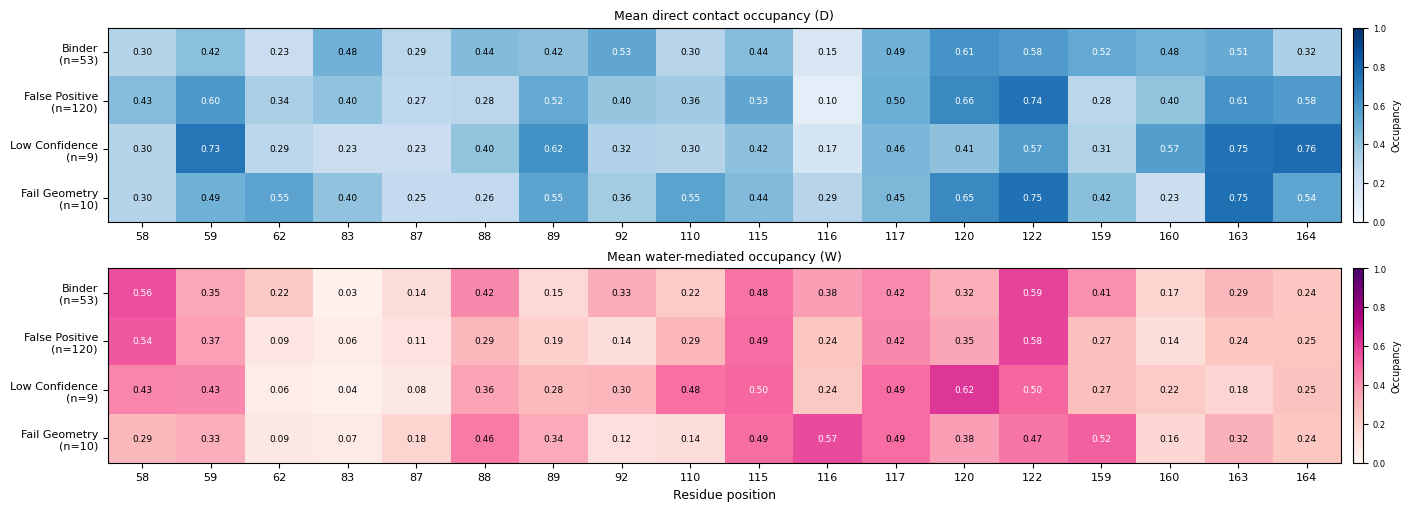

In [9]:
# ── HEATMAPS: MEAN D AND MEAN W PER GROUP ────────────────────────────────────
# Two heatmaps stacked vertically — D on top, W below.
# Colour scale: white (0) → full colour (1.0), sequential.

d_matrix = np.array([[dw_stats[grp]['D'][res]['mean'] for res in res_labels]
                      for grp in groups_present])
w_matrix = np.array([[dw_stats[grp]['W'][res]['mean'] for res in res_labels]
                      for grp in groups_present])

y_labels = [f"{g}\n(n={dw_stats[g]['D'][res_labels[0]]['n']})" for g in groups_present]

fig, (ax_d, ax_w) = plt.subplots(2, 1, figsize=(14, 5),
                                   constrained_layout=True)

for ax, matrix, title, cmap, color in [
    (ax_d, d_matrix, 'Mean direct contact occupancy (D)', 'Blues',  '#648FFF'),
    (ax_w, w_matrix, 'Mean water-mediated occupancy (W)',  'RdPu',   '#DC267F'),
]:
    im = ax.imshow(matrix, aspect='auto', cmap=cmap, vmin=0, vmax=1)

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=6.5,
                    color='white' if v > 0.5 else 'black')

    ax.set_xticks(range(len(res_labels)))
    ax.set_xticklabels(res_labels, fontsize=8)
    ax.set_yticks(range(len(groups_present)))
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_title(title, fontsize=9)

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.01)
    cbar.set_label('Occupancy', fontsize=7)
    cbar.ax.tick_params(labelsize=6)

ax_d.set_xlabel('')
ax_w.set_xlabel('Residue position', fontsize=9)

plt.show()

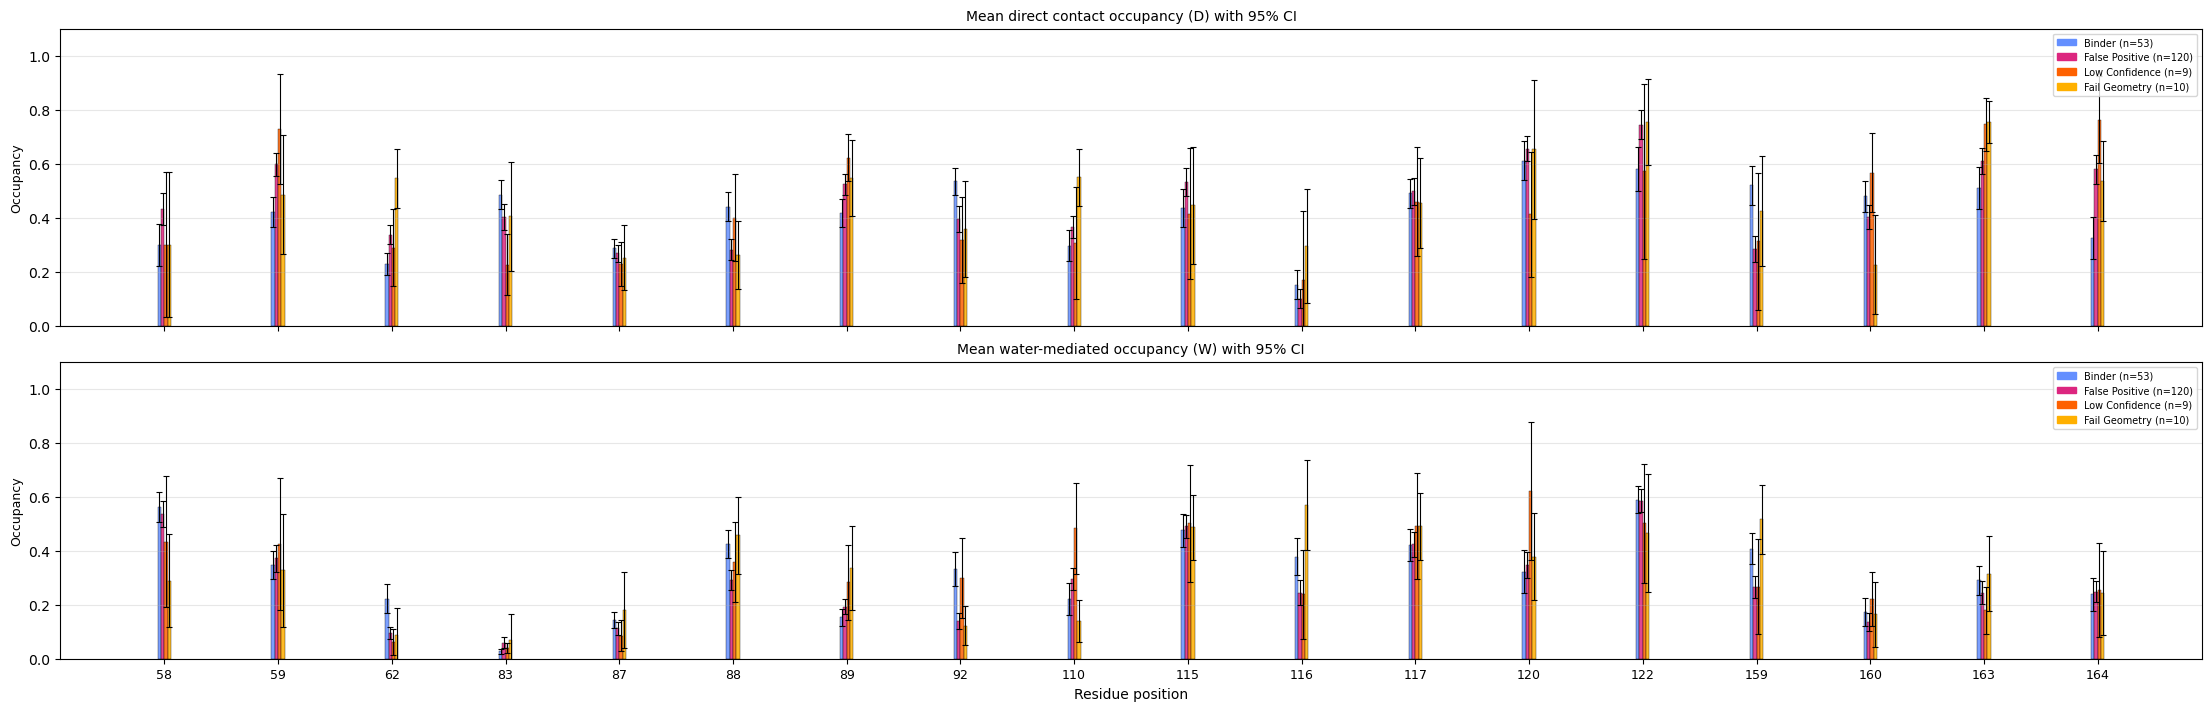

In [10]:
# ── BAR PLOTS: D AND W SIDE BY SIDE ──────────────────────────────────────────
# One subplot per residue, showing D (left bar) and W (right bar) for each group.
# Useful for spotting residues where D and W diverge across groups.

n_res  = len(res_labels)
n_grp  = len(groups_present)
bw     = 0.35 / n_grp        # bar width within each D or W cluster
x      = np.arange(n_res) * 3 # spacing between residue clusters

fig, (ax_d, ax_w) = plt.subplots(2, 1, figsize=(22, 7),
                                   constrained_layout=True, sharex=True)

for ax, feature, title in [
    (ax_d, 'D', 'Mean direct contact occupancy (D) with 95% CI'),
    (ax_w, 'W', 'Mean water-mediated occupancy (W) with 95% CI'),
]:
    for i, grp in enumerate(groups_present):
        offsets = x - 0.35/2 + bw * (i + 0.5)
        means   = [dw_stats[grp][feature][res]['mean'] for res in res_labels]
        cis     = [dw_stats[grp][feature][res]['ci']   for res in res_labels]
        n       = dw_stats[grp][feature][res_labels[0]]['n']
        ax.bar(offsets, means, width=bw,
               color=GROUP_COLORS[grp], label=f'{grp} (n={n})',
               alpha=0.85, edgecolor='k', linewidth=0.3)
        ax.errorbar(offsets, means, yerr=cis,
                    fmt='none', color='k', linewidth=0.8,
                    capsize=2, capthick=0.8)

    ax.set_ylabel('Occupancy', fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    handles = [mpatches.Patch(color=GROUP_COLORS[g],
                               label=f"{g} (n={dw_stats[g][feature][res_labels[0]]['n']})")
               for g in groups_present]
    ax.legend(handles=handles, fontsize=7, loc='upper right')

ax_w.set_xticks(x)
ax_w.set_xticklabels(res_labels, fontsize=9)
ax_w.set_xlabel('Residue position', fontsize=10)

plt.show()

# DW Distributions

In [11]:
# ── LOAD D/W CSV AND COMPUTE SUMMARY STATISTICS ──────────────────────────────
import os
from scipy.stats import gaussian_kde

DW_CSV_PATH = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/dw_scores_all_sequences_40_500ns_ml.csv"
POCKET_RES  = [58, 59, 62, 83, 87, 88, 89, 92, 110, 115, 116, 117, 120, 122, 159, 160, 163, 164]

df_dw = pd.read_csv(DW_CSV_PATH)
print(f"Loaded: {len(df_dw)} sequences")
print(df_dw['seq_type'].value_counts().to_string())

# Build column lists for pocket residues
D_PKT = [f"D_{r}" for r in POCKET_RES]
W_PKT = [f"W_{r}" for r in POCKET_RES]

# ── Summary statistics per residue per group ──────────────────────────────────
grps = [g for g in GROUP_ORDER if g in df_dw['seq_type'].values]

header = f"{'Residue':<8}{'Contact':<10}"
for grp in grps:
    n = len(df_dw[df_dw['seq_type'] == grp])
    header += f"  {(grp[:12]+' (n='+str(n)+')'):<22}"
print(header)
print('-' * len(header))

for res, d_col, w_col in zip(POCKET_RES, D_PKT, W_PKT):
    for contact, col in [('D', d_col), ('W', w_col)]:
        row = f"{res:<8}{contact:<10}"
        for grp in grps:
            vals = df_dw[df_dw['seq_type'] == grp][col].dropna()
            row += f"  mean={vals.mean():.3f} sd={vals.std():.3f} med={vals.median():.3f}  "
        print(row)


Loaded: 192 sequences
seq_type
False Positive    120
Binder             53
Fail Geometry      10
Low Confidence      9
Residue Contact     Binder (n=53)           False Positi (n=120)    Low Confiden (n=9)      Fail Geometr (n=10)   
------------------------------------------------------------------------------------------------------------------
58      D           mean=0.299 sd=0.277 med=0.241    mean=0.433 sd=0.327 med=0.461    mean=0.300 sd=0.349 med=0.106    mean=0.300 sd=0.377 med=0.045  
58      W           mean=0.562 sd=0.204 med=0.602    mean=0.537 sd=0.267 med=0.644    mean=0.433 sd=0.316 med=0.453    mean=0.289 sd=0.240 med=0.249  
59      D           mean=0.421 sd=0.206 med=0.438    mean=0.597 sd=0.240 med=0.603    mean=0.728 sd=0.265 med=0.845    mean=0.485 sd=0.309 med=0.472  
59      W           mean=0.347 sd=0.192 med=0.354    mean=0.372 sd=0.278 med=0.336    mean=0.426 sd=0.318 med=0.364    mean=0.327 sd=0.292 med=0.229  
62      D           mean=0.227 sd=0.150 med=0.1

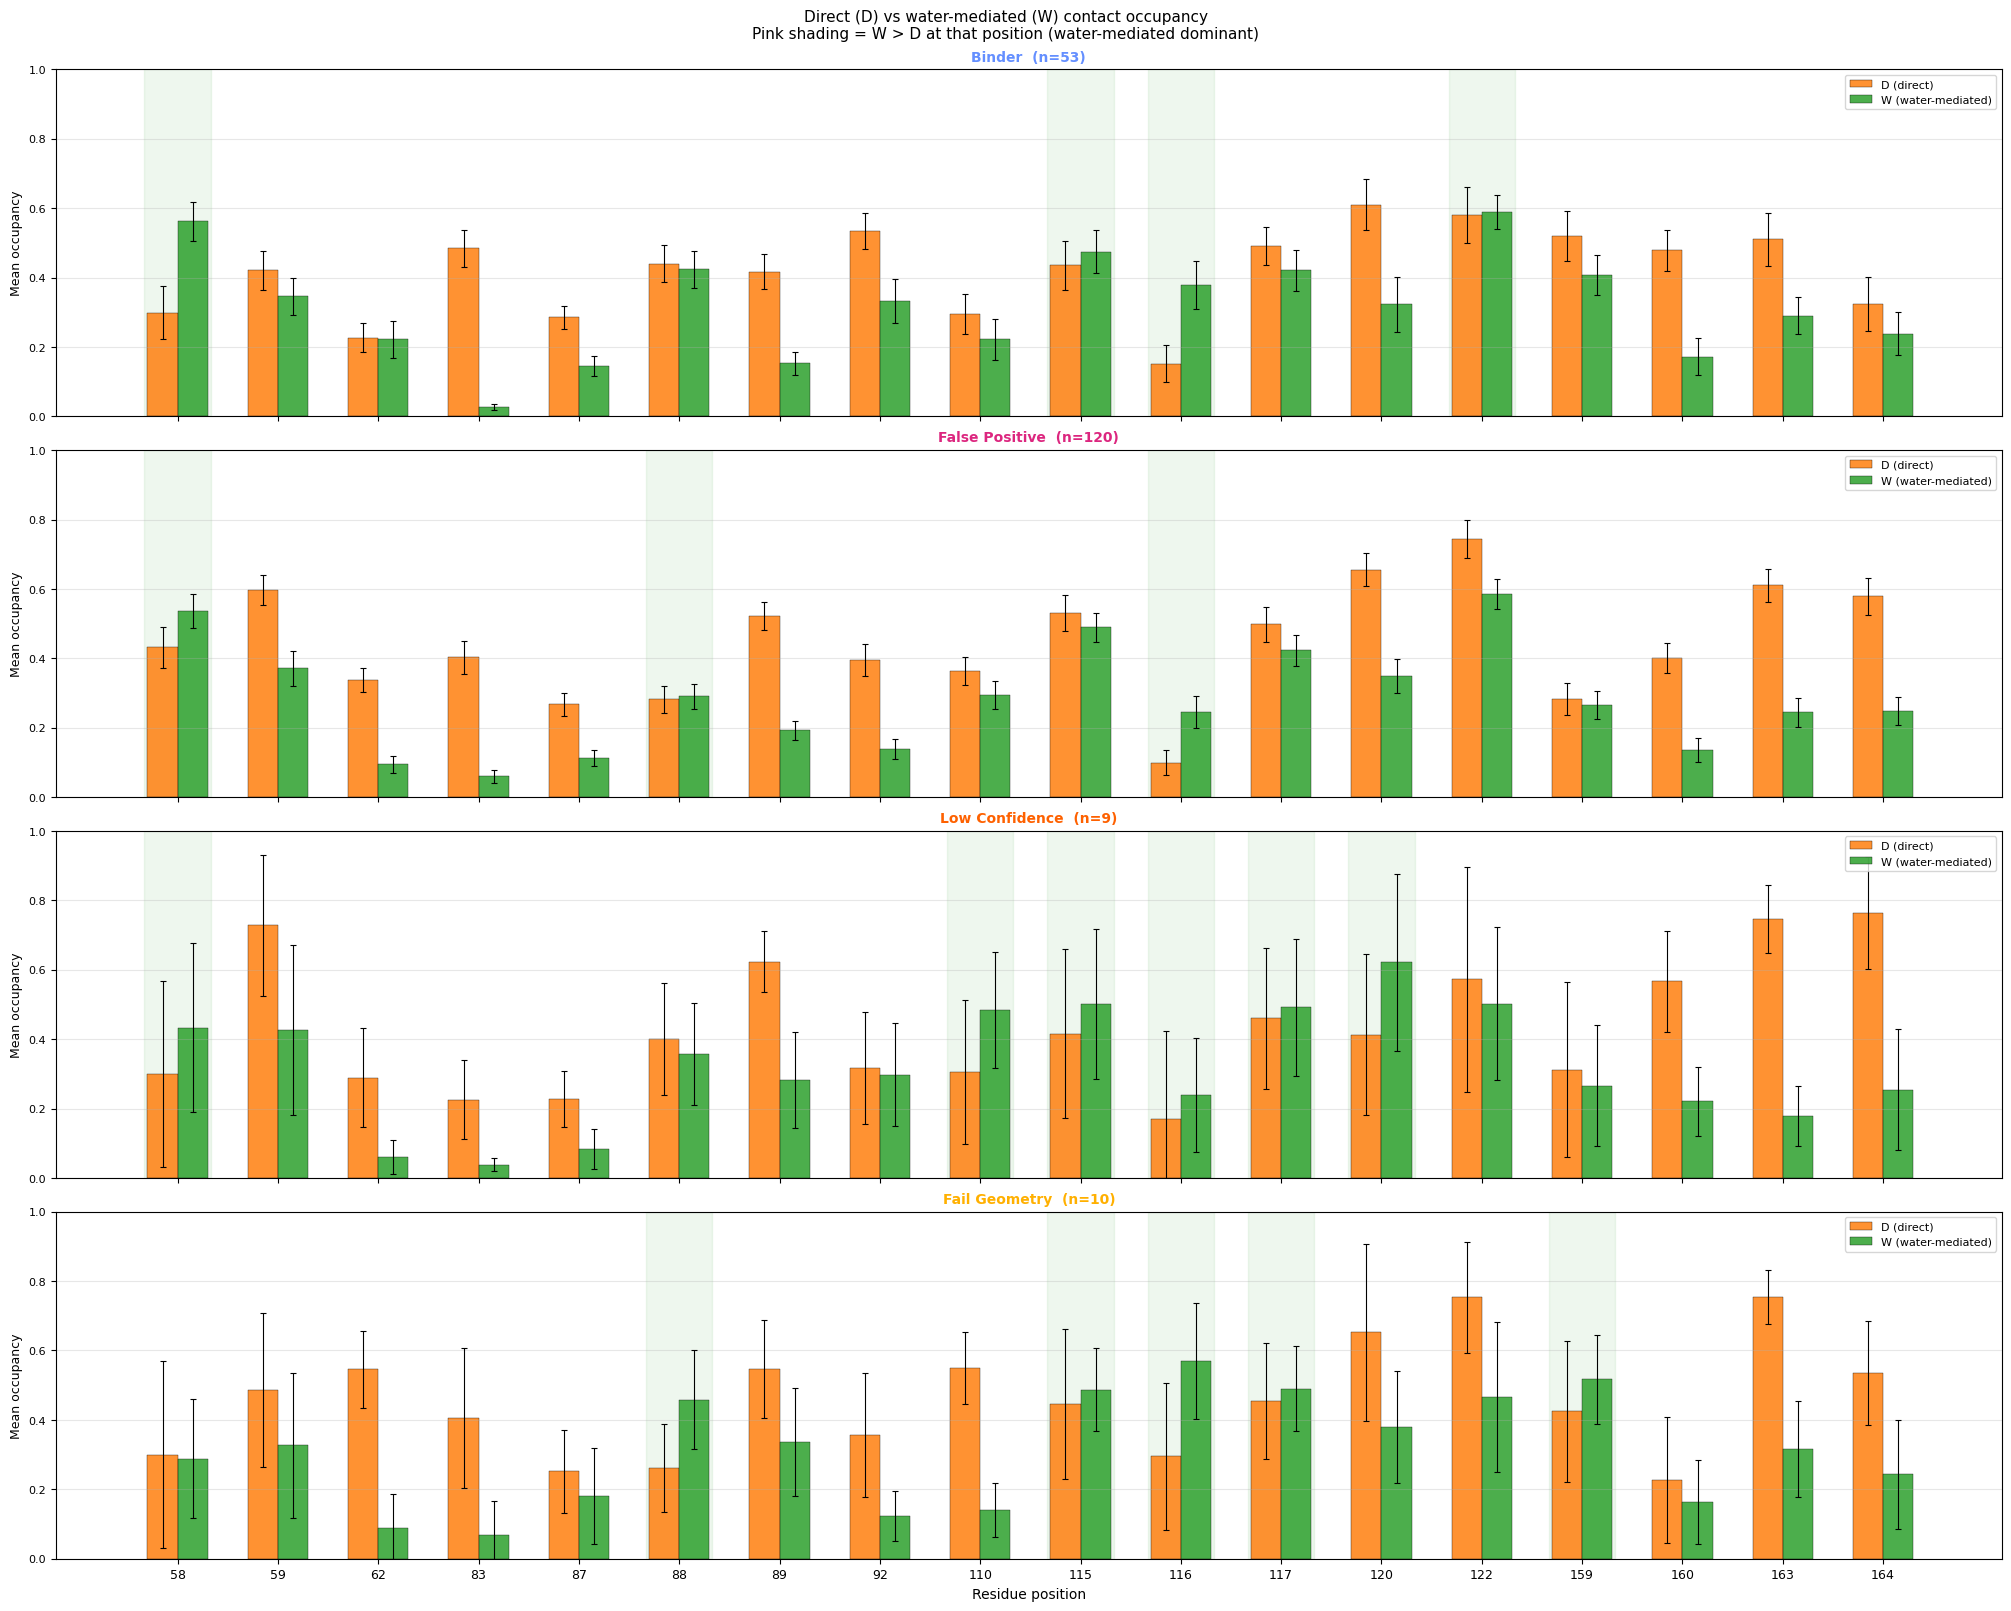

Saved -> /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/analysis_plots_500ns/dw_dominant_interaction.png


In [12]:
# ── D vs W PAIRED BAR PLOT: DOMINANT INTERACTION TYPE PER POSITION ──────────
# One subplot per sequence group. Within each subplot, paired D (blue) and
# W (pink) bars at each residue show whether direct or water-mediated contact
# dominates at that position for that group.
# D > W → direct contact dominant   (blue bar taller)
# W > D → water-mediated dominant   (pink bar taller)

grps  = [g for g in GROUP_ORDER if g in df_dw['seq_type'].values]
n_res = len(POCKET_RES)
x     = np.arange(n_res) * 2   # spacing=2 between residue clusters
bw    = 0.6                     # width of each individual bar

D_COLOR = 'C1'   # blue  — direct contact
W_COLOR = 'C2'   # pink  — water-mediated contact

fig, axes = plt.subplots(len(grps), 1,
                          figsize=(20, 4 * len(grps)),
                          constrained_layout=True,
                          sharex=True)

for ax, grp in zip(axes, grps):
    sub  = df_dw[df_dw['seq_type'] == grp]
    n    = len(sub)

    d_means = sub[[f"D_{r}" for r in POCKET_RES]].mean().values
    w_means = sub[[f"W_{r}" for r in POCKET_RES]].mean().values
    d_cis   = (stats.t.ppf(0.975, df=n-1) *
               sub[[f"D_{r}" for r in POCKET_RES]].std().values / np.sqrt(n))
    w_cis   = (stats.t.ppf(0.975, df=n-1) *
               sub[[f"W_{r}" for r in POCKET_RES]].std().values / np.sqrt(n))

    # D bars: left of centre; W bars: right of centre
    ax.bar(x - bw/2, d_means, width=bw, color=D_COLOR, alpha=0.85,
           edgecolor='k', linewidth=0.3, label='D (direct)')
    ax.bar(x + bw/2, w_means, width=bw, color=W_COLOR, alpha=0.85,
           edgecolor='k', linewidth=0.3, label='W (water-mediated)')

    ax.errorbar(x - bw/2, d_means, yerr=d_cis,
                fmt='none', color='k', linewidth=0.8, capsize=2.5, capthick=0.8)
    ax.errorbar(x + bw/2, w_means, yerr=w_cis,
                fmt='none', color='k', linewidth=0.8, capsize=2.5, capthick=0.8)

    # Shade positions where W > D (water-mediated dominant)
    for i, (d, w) in enumerate(zip(d_means, w_means)):
        if w > d:
            ax.axvspan(x[i] - bw*1.1, x[i] + bw*1.1,
                       alpha=0.08, color=W_COLOR, zorder=0)

    ax.set_ylabel('Mean occupancy', fontsize=9)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{grp}  (n={n})", fontsize=10, fontweight='bold',
                 color=GROUP_COLORS[grp])
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc='upper right')

axes[-1].set_xticks(x)
axes[-1].set_xticklabels([str(r) for r in POCKET_RES], fontsize=9)
axes[-1].set_xlabel('Residue position', fontsize=10)

fig.suptitle('Direct (D) vs water-mediated (W) contact occupancy\n'
             'Pink shading = W > D at that position (water-mediated dominant)',
             fontsize=11)

save_path = os.path.join(
    "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/analysis_plots_500ns",
    'dw_dominant_interaction.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved -> {save_path}")


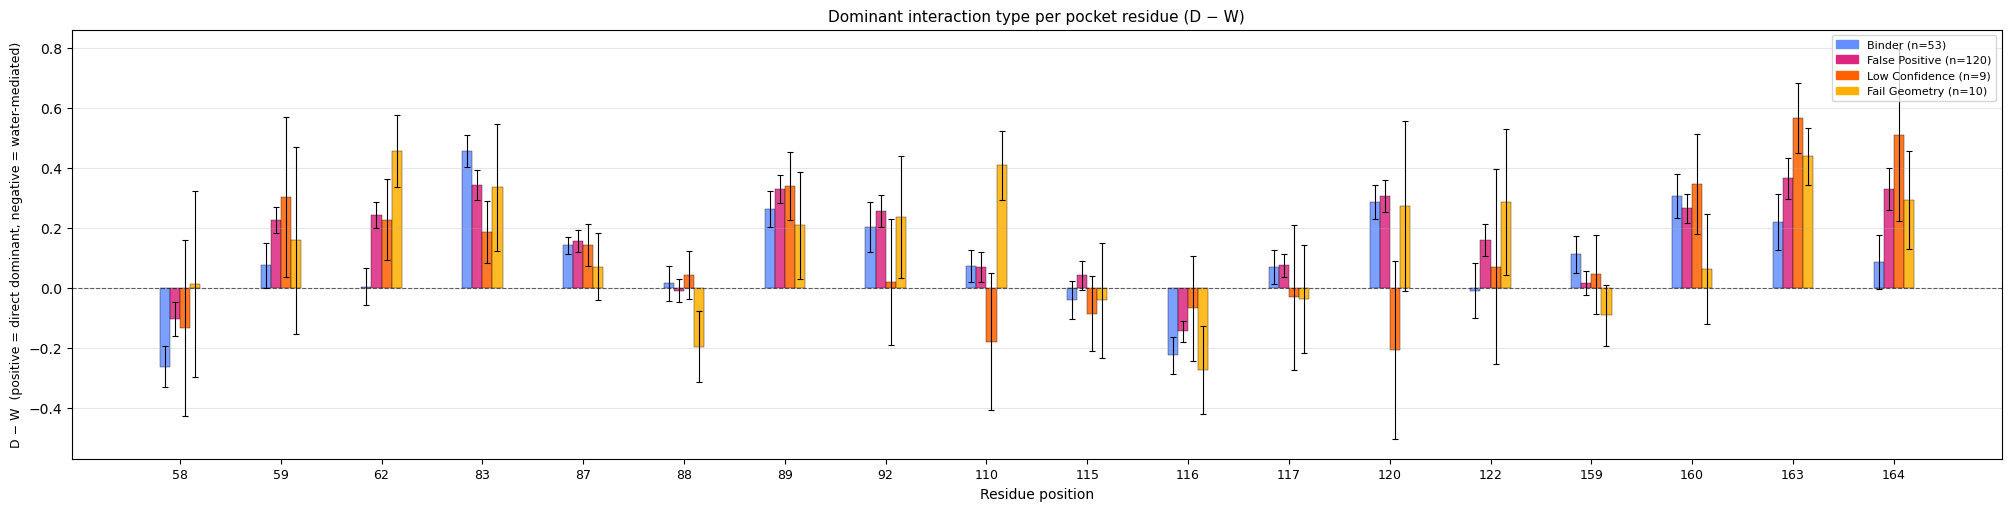

In [13]:
# ── D minus W: dominant interaction type summary ──────────────────────────────
grps  = [g for g in GROUP_ORDER if g in df_dw['seq_type'].values]
n_res = len(POCKET_RES)
x     = np.arange(n_res) * 2
bw    = 0.8 / len(grps)

fig, ax = plt.subplots(figsize=(20, 5), constrained_layout=True)

for i, grp in enumerate(grps):
    sub     = df_dw[df_dw['seq_type'] == grp]
    n       = len(sub)
    d_means = sub[[f"D_{r}" for r in POCKET_RES]].mean().values
    w_means = sub[[f"W_{r}" for r in POCKET_RES]].mean().values
    diff    = d_means - w_means
    cis     = (stats.t.ppf(0.975, df=n-1) *
               (sub[[f"D_{r}" for r in POCKET_RES]].values -
                sub[[f"W_{r}" for r in POCKET_RES]].values).std(axis=0) / np.sqrt(n))
    offsets = x - 0.4 + bw * (i + 0.5)

    ax.bar(offsets, diff, width=bw, color=GROUP_COLORS[grp],
           label=f"{grp} (n={n})", alpha=0.85, edgecolor='k', linewidth=0.3)
    ax.errorbar(offsets, diff, yerr=cis,
                fmt='none', color='k', linewidth=0.8, capsize=2.5, capthick=0.8)

ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([str(r) for r in POCKET_RES], fontsize=9)
ax.set_xlabel('Residue position', fontsize=10)
ax.set_ylabel('D − W  (positive = direct dominant, negative = water-mediated)', fontsize=9)
ax.set_title('Dominant interaction type per pocket residue (D − W)', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
handles = [mpatches.Patch(color=GROUP_COLORS[g],
                           label=f"{g} (n={len(df_dw[df_dw['seq_type']==g])})")
           for g in grps]
ax.legend(handles=handles, fontsize=8, loc='upper right')

save_path = os.path.join(
    "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/analysis_plots_500ns",
    'dw_diff_summary.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

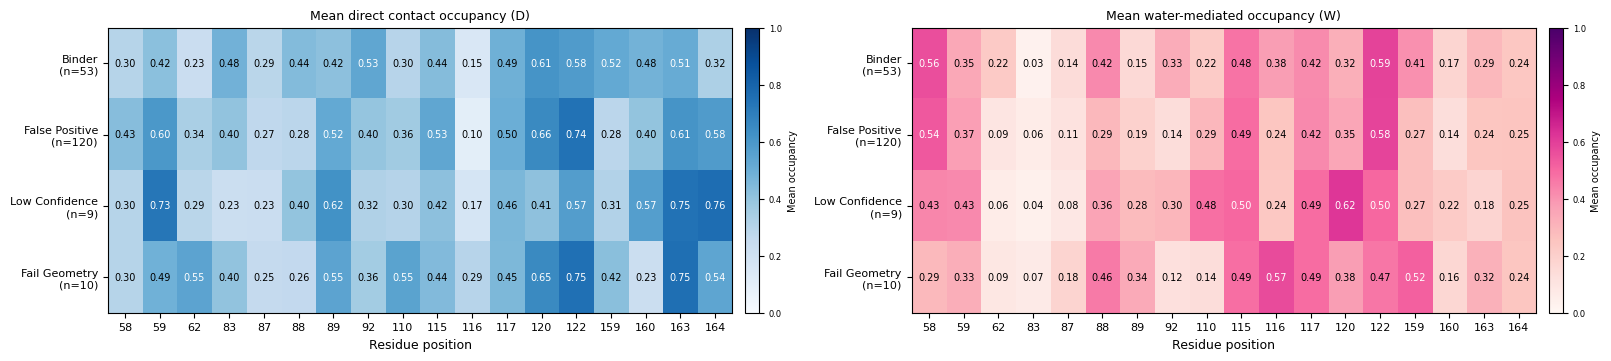

Saved -> /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/analysis_plots_500ns/dw_heatmap_pocket.png


In [14]:
# ── HEATMAP: MEAN D AND W FOR POCKET RESIDUES ────────────────────────────────
grps     = [g for g in GROUP_ORDER if g in df_dw['seq_type'].values]
res_lbls = [str(r) for r in POCKET_RES]

d_mat = np.array([[df_dw[df_dw['seq_type'] == g][f"D_{r}"].mean()
                   for r in POCKET_RES] for g in grps])
w_mat = np.array([[df_dw[df_dw['seq_type'] == g][f"W_{r}"].mean()
                   for r in POCKET_RES] for g in grps])

y_lbls = [f"{g}\n(n={len(df_dw[df_dw['seq_type']==g])})" for g in grps]

fig, (ax_d, ax_w) = plt.subplots(1, 2, figsize=(16, 3.5),
                                   constrained_layout=True)

for ax, mat, title, cmap in [
    (ax_d, d_mat, 'Mean direct contact occupancy (D)',  'Blues'),
    (ax_w, w_mat, 'Mean water-mediated occupancy (W)',  'RdPu'),
]:
    im = ax.imshow(mat, aspect='auto', cmap=cmap, vmin=0, vmax=1)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            ax.text(j, i, f"{v:.2f}", ha='center', va='center',
                    fontsize=7, color='white' if v > 0.5 else 'black')
    ax.set_xticks(range(len(POCKET_RES)))
    ax.set_xticklabels(res_lbls, fontsize=8)
    ax.set_yticks(range(len(grps)))
    ax.set_yticklabels(y_lbls, fontsize=8)
    ax.set_xlabel('Residue position', fontsize=9)
    ax.set_title(title, fontsize=9)
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label('Mean occupancy', fontsize=7)
    cbar.ax.tick_params(labelsize=6)

save_path = os.path.join(
    "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/analysis_plots_500ns",
    'dw_heatmap_pocket.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved -> {save_path}")


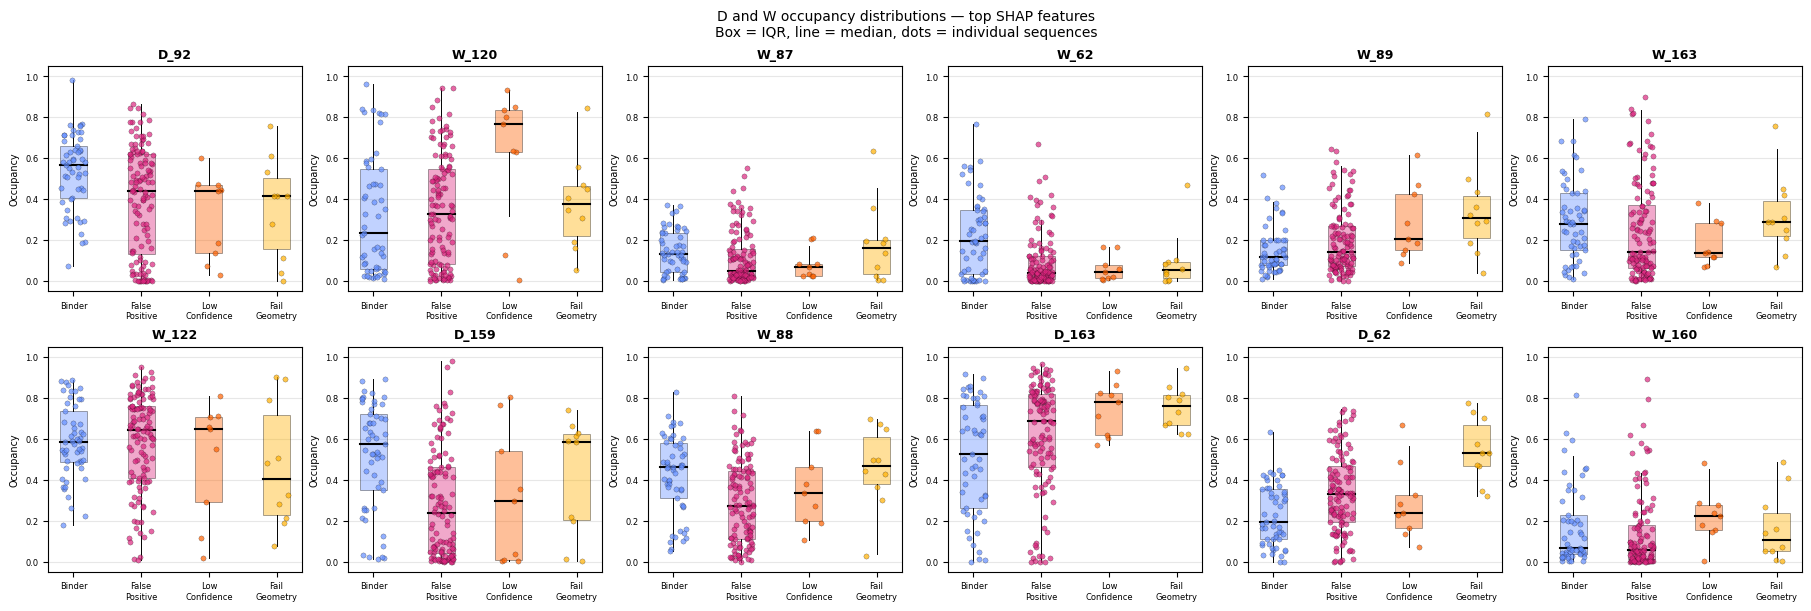

Saved -> /Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/analysis_plots_500ns/dw_strip_top_shap.png


In [15]:
# ── BOX + STRIP PLOTS FOR TOP SHAP FEATURES ──────────────────────────────────
TOP_SHAP = ['D_92','W_120','W_87','W_62','W_89',
            'W_163','W_122','D_159','W_88','D_163','D_62','W_160']

grps = [g for g in GROUP_ORDER if g in df_dw['seq_type'].values]
rng  = np.random.default_rng(42)

fig, axes = plt.subplots(2, 6, figsize=(18, 6), constrained_layout=True)
axes_flat = axes.flatten()

for ax, feat in zip(axes_flat, TOP_SHAP):
    for i, grp in enumerate(grps):
        vals   = df_dw[df_dw['seq_type'] == grp][feat].dropna().values
        jitter = rng.uniform(-0.18, 0.18, size=len(vals))

        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        iqr = q3 - q1
        lo  = max(vals.min(), q1 - 1.5 * iqr)
        hi  = min(vals.max(), q3 + 1.5 * iqr)

        rect = plt.Rectangle((i - 0.2, q1), 0.4, iqr,
                               facecolor=GROUP_COLORS[grp], edgecolor='k',
                               linewidth=0.6, alpha=0.4, zorder=2)
        ax.add_patch(rect)
        ax.plot([i - 0.2, i + 0.2], [med, med],
                color='k', linewidth=1.5, zorder=4)
        ax.plot([i, i], [lo, q1], color='k', linewidth=0.7, zorder=3)
        ax.plot([i, i], [q3, hi], color='k', linewidth=0.7, zorder=3)
        ax.scatter(i + jitter, vals,
                   color=GROUP_COLORS[grp], s=14, alpha=0.7,
                   edgecolors='k', linewidths=0.2, zorder=5)

    ax.set_xticks(range(len(grps)))
    ax.set_xticklabels([g.replace(' ', '\n') for g in grps], fontsize=6)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_ylabel('Occupancy', fontsize=7)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3, axis='y')
    ax.tick_params(labelsize=6)

fig.suptitle('D and W occupancy distributions — top SHAP features\n'
             'Box = IQR, line = median, dots = individual sequences',
             fontsize=10)

save_path = os.path.join(
    "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/water_analysis/analysis_plots_500ns",
    'dw_strip_top_shap.png')
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved -> {save_path}")
